In [1]:
# importar librerias
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

1. Importar DataFrame

In [2]:
# importar dataframe
df = pd.read_csv('https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Sesion_07_housing.csv')


In [3]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


2. Entender el estado de los datos, para ello puedo emplear los comandos básicos del pandas

df.info()

df.describe()

df.isnull().sum()

df.isna().sum()

Estos dos últimos son equivalentes.


In [4]:
df.info()  ## muestras las columnas caracteristicas, 
#numero de valores no nulos y el tipo de dato de cada columna.
#total bedrooms tiene valores nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
df.describe() # calcula estadisticas descriptivas de las columnas numericas del dataframe.

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
df.isnull().sum() # muestra el numero de valores nulos por columna

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [7]:
df.isna().sum() # alternativa a df.isnull

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

3. ¿Cuántas variables tiene el dataset y de qué tipo son?

In [8]:
df.dtypes  # ocean_proximity es object y todas las demas son floats

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

4. ¿Existen valores faltantes? ¿En qué variables estan? ¿cuántos son? \
La única variable con valores faltantes es total_bedrooms con 207, como se ve de usar df.isnull().


5 Determinar los elementos únicos dentro de la columna ocean_proximity.

Los tipos de elementos son NEAR BAY, 1H OCEAN, INLAND, NEAR OCEAN E ISLAND.

In [9]:
op_tipos = df['ocean_proximity'].unique()

6. Determinar el promedio de cada una de las columnas  de cols asociado a cada elementos unico de ocean_proximity, intenta con la operación groupby.

In [10]:
cols = ["housing_median_age",	"total_rooms",	"total_bedrooms",	"population",	"households",	"median_income",	"median_house_value"]

In [11]:
df.groupby('ocean_proximity')[cols].mean()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
ocean_proximity,,,,,,,
<1H OCEAN,29.279225,2628.343586,546.539185,1520.290499,517.744965,4.230682,240084.285464
INLAND,24.271867,2717.742787,533.881619,1391.046252,477.447565,3.208996,124805.392001
ISLAND,42.400000,1574.600000,420.400000,668.000000,276.600000,2.744420,380440.000000
NEAR BAY,37.730131,2493.589520,514.182819,1230.317467,488.616157,4.172885,259212.311790
NEAR OCEAN,29.347254,2583.700903,538.615677,1354.008653,501.244545,4.005785,249433.977427


7. Construye un histograma para cada columna, puede emplear la libreria de seaborn.

In [12]:
df[df['ocean_proximity']=='ISLAND'] ## los datos con proximidad oceánica ISLAND son muy pocos.

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
8314,-118.32,33.35,27.0,1675.0,521.0,744.0,331.0,2.1579,450000.0,ISLAND
8315,-118.33,33.34,52.0,2359.0,591.0,1100.0,431.0,2.8333,414700.0,ISLAND
8316,-118.32,33.33,52.0,2127.0,512.0,733.0,288.0,3.3906,300000.0,ISLAND
8317,-118.32,33.34,52.0,996.0,264.0,341.0,160.0,2.7361,450000.0,ISLAND
8318,-118.48,33.43,29.0,716.0,214.0,422.0,173.0,2.6042,287500.0,ISLAND


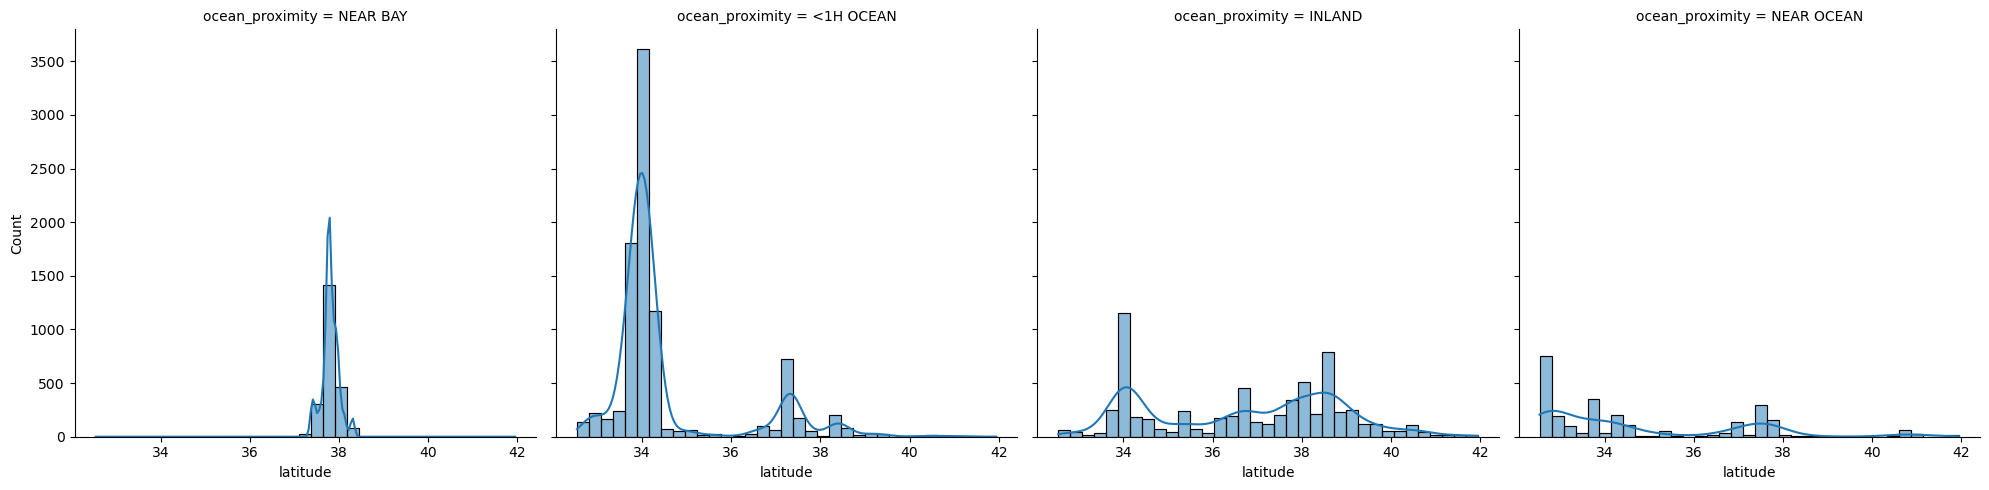

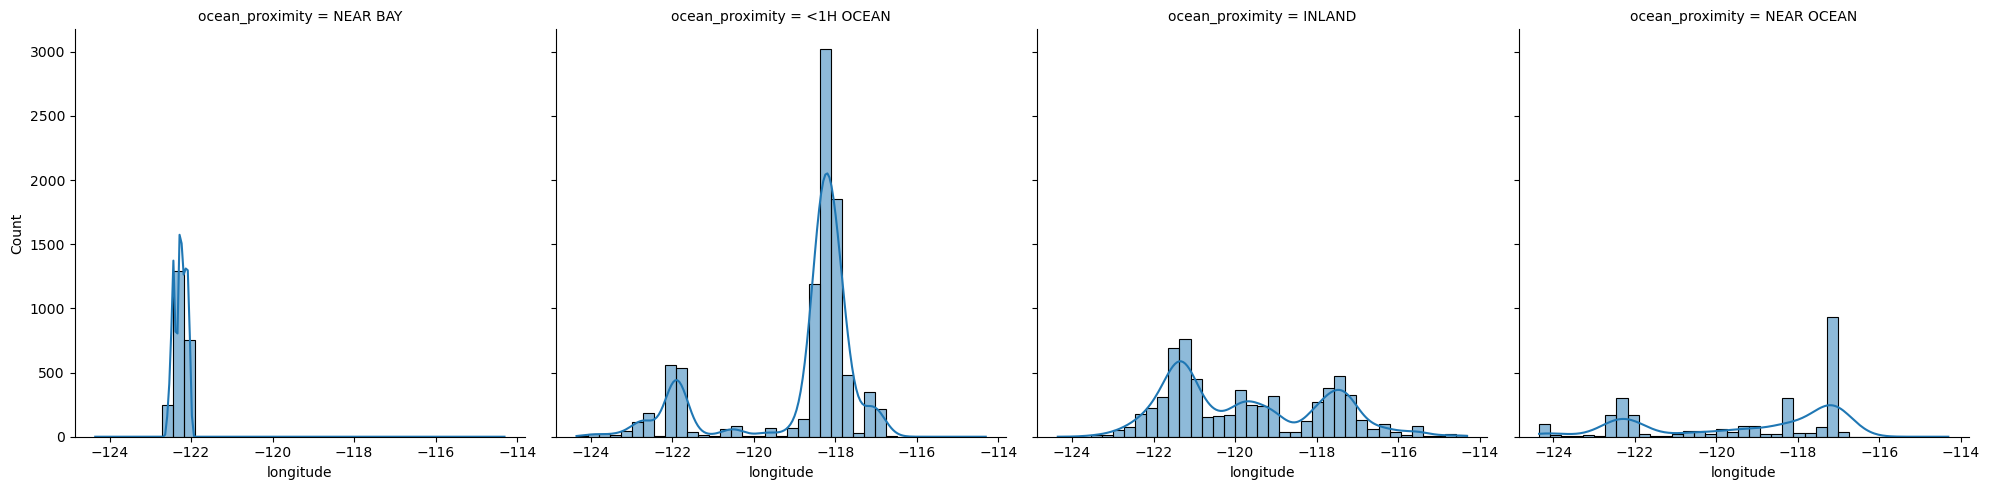

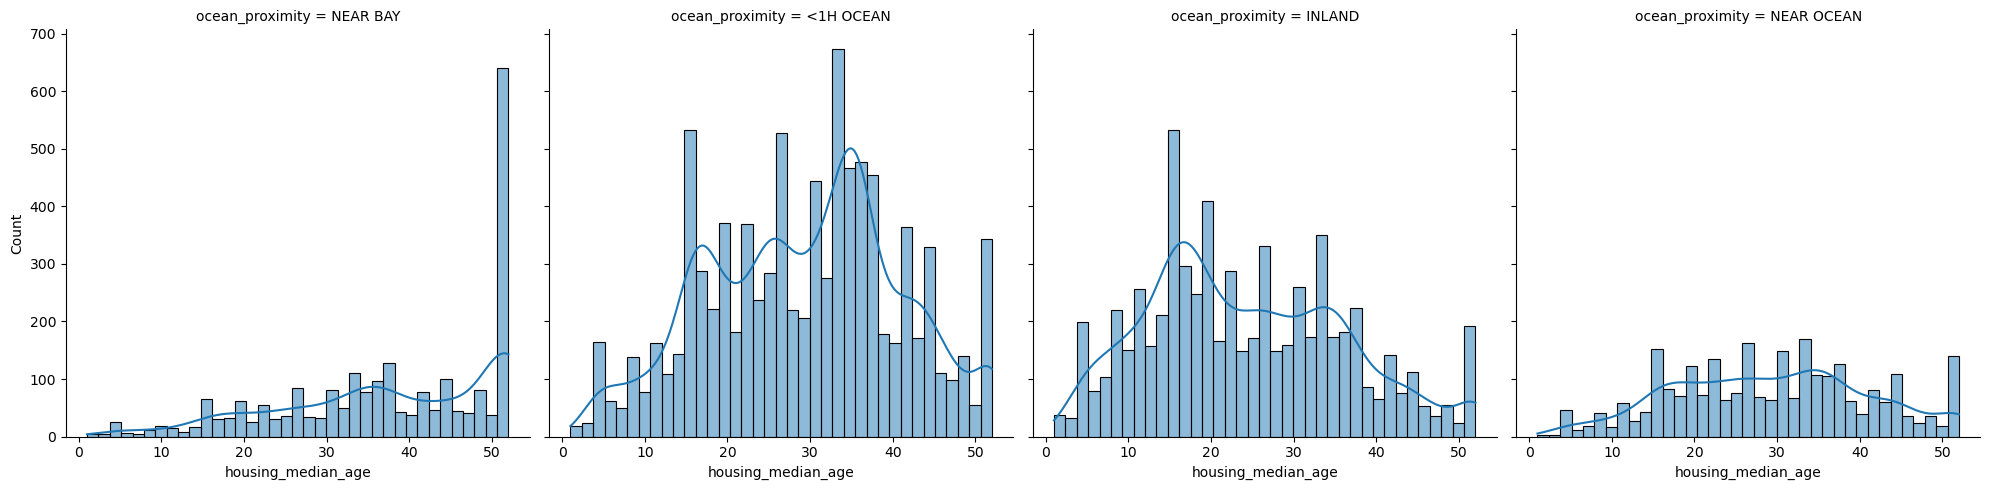

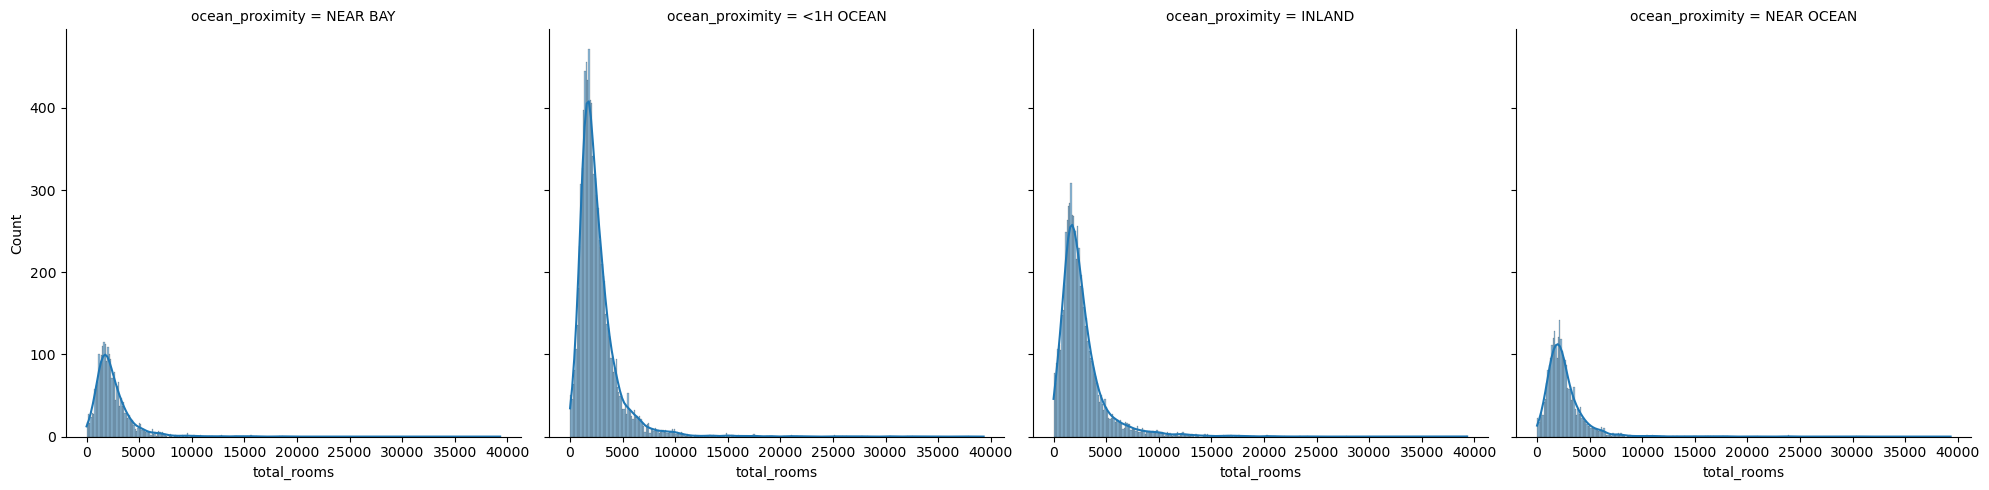

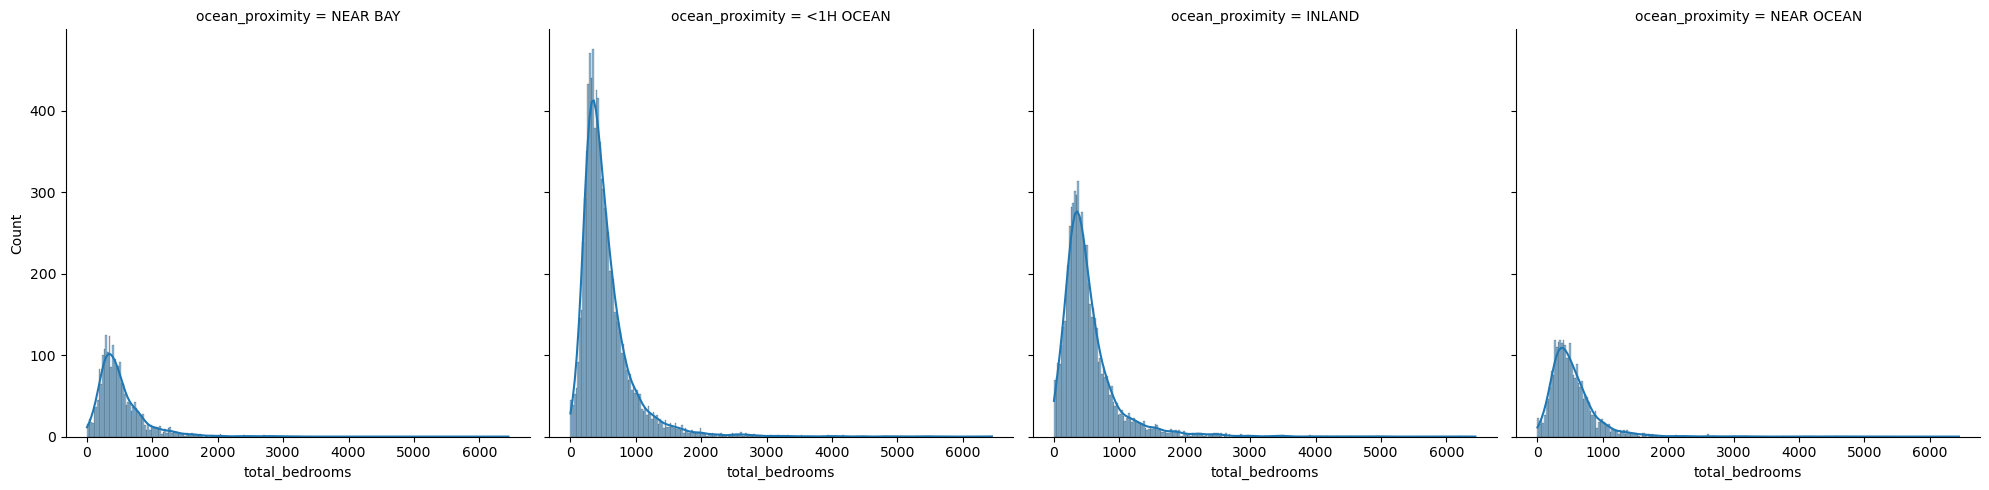

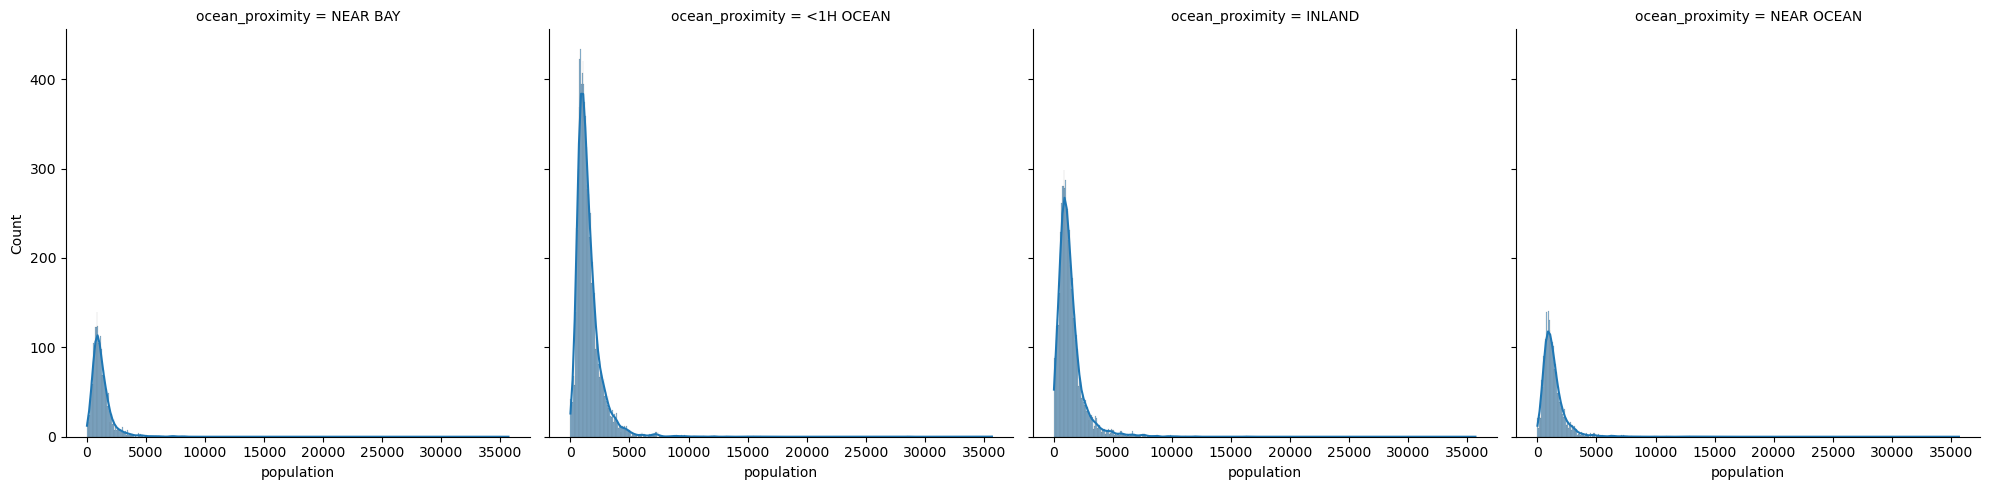

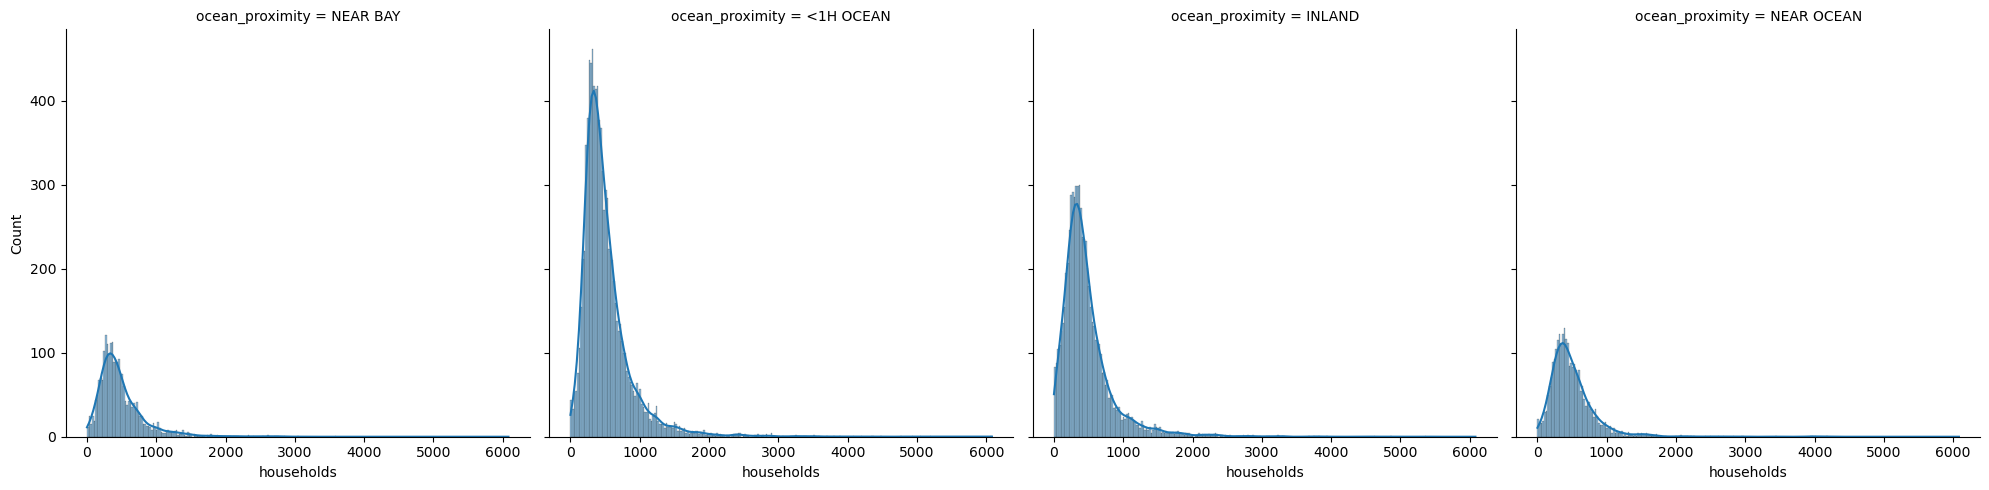

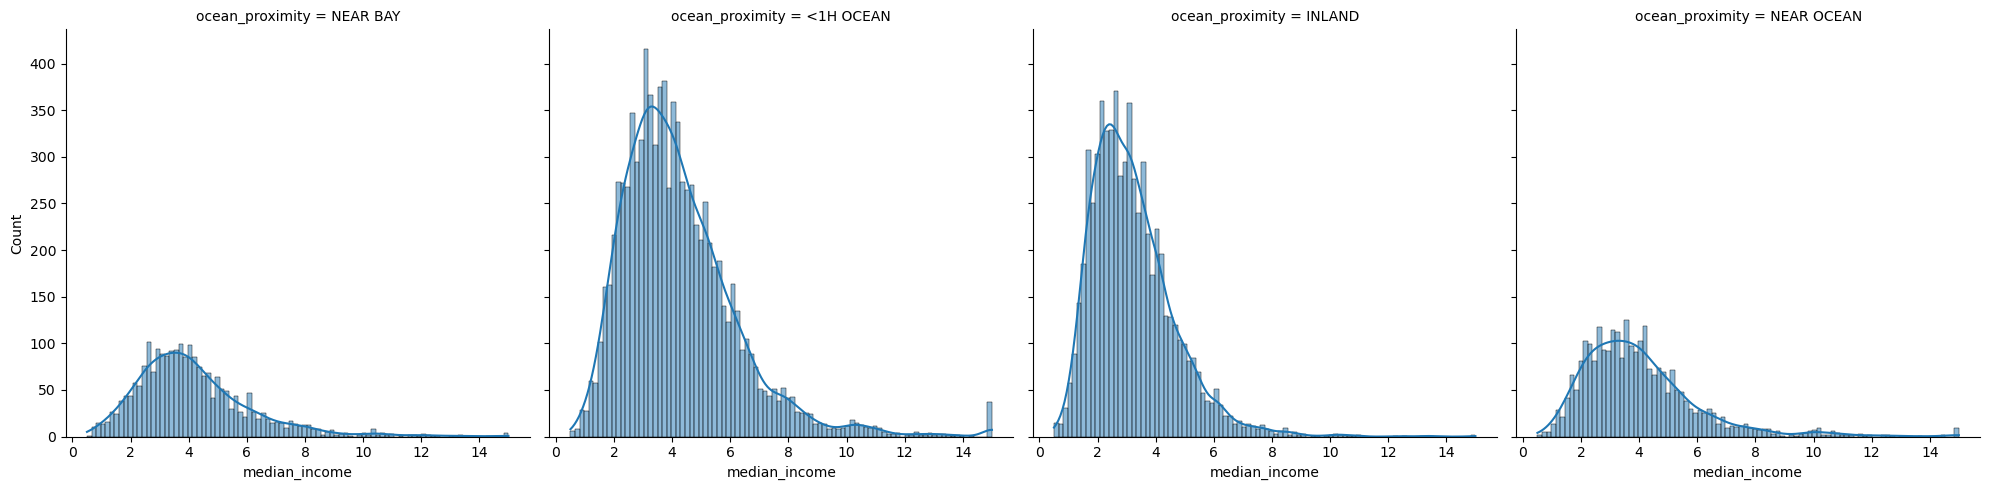

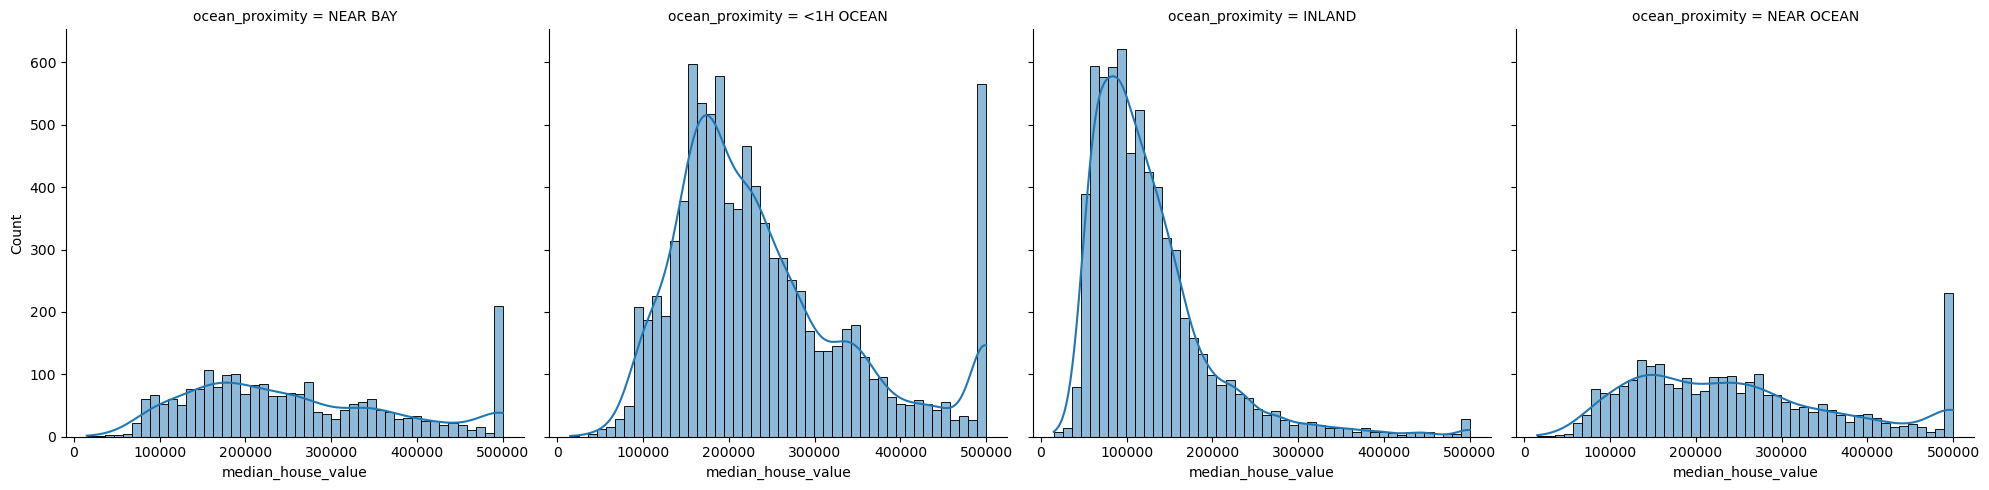

In [13]:
lista_columnas = ["latitude", "longitude", "housing_median_age",	"total_rooms",	"total_bedrooms",	"population",	"households",	"median_income",	"median_house_value"]

for columna in lista_columnas:
    sns.displot(data = df[df['ocean_proximity'] != 'ISLAND'], x = columna, col='ocean_proximity', kind='hist', kde=True)

8. Grafique el boxplot de median_houde_value por ocean_aproximity para cada ciudad.

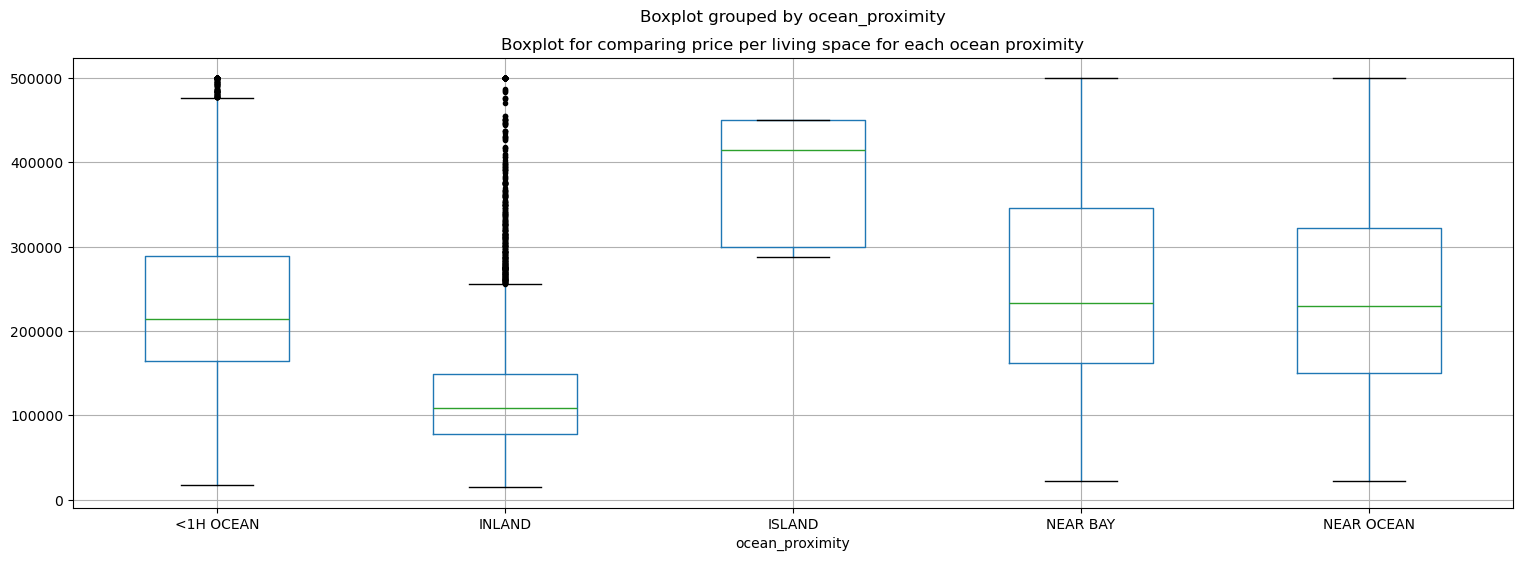

In [14]:
#draw boxplot
df.boxplot(column="median_house_value", by="ocean_proximity", sym = "k.", figsize=(18,6))
#set title
plt.title('Boxplot for comparing price per living space for each ocean proximity')
plt.show()

9. Determine la matriz de correlación.

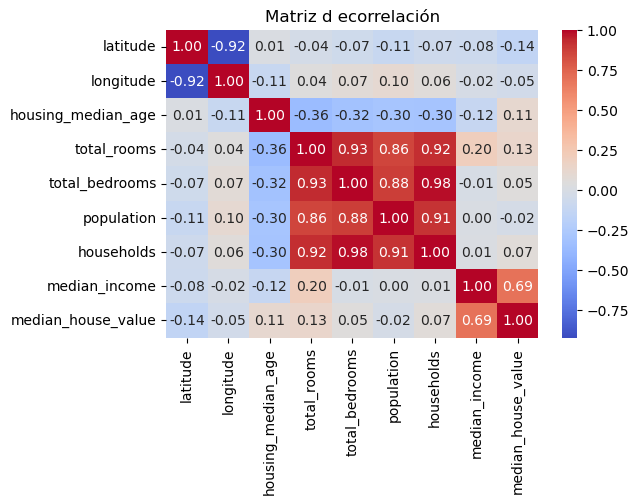

In [15]:
columnas = ["latitude", "longitude", "housing_median_age",	"total_rooms",	"total_bedrooms",	"population",	"households",	"median_income",	"median_house_value", "ocean_aproximity"]

plt.figure(figsize=(6,4))
sns.heatmap(df[lista_columnas].corr(method='pearson'), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz d ecorrelación')
plt.show()

10. Con las columnas "median_house_value", "median_income", "total_rooms","housing_median_age"], realiza un grafico pairplot empleando seaborn de python.]

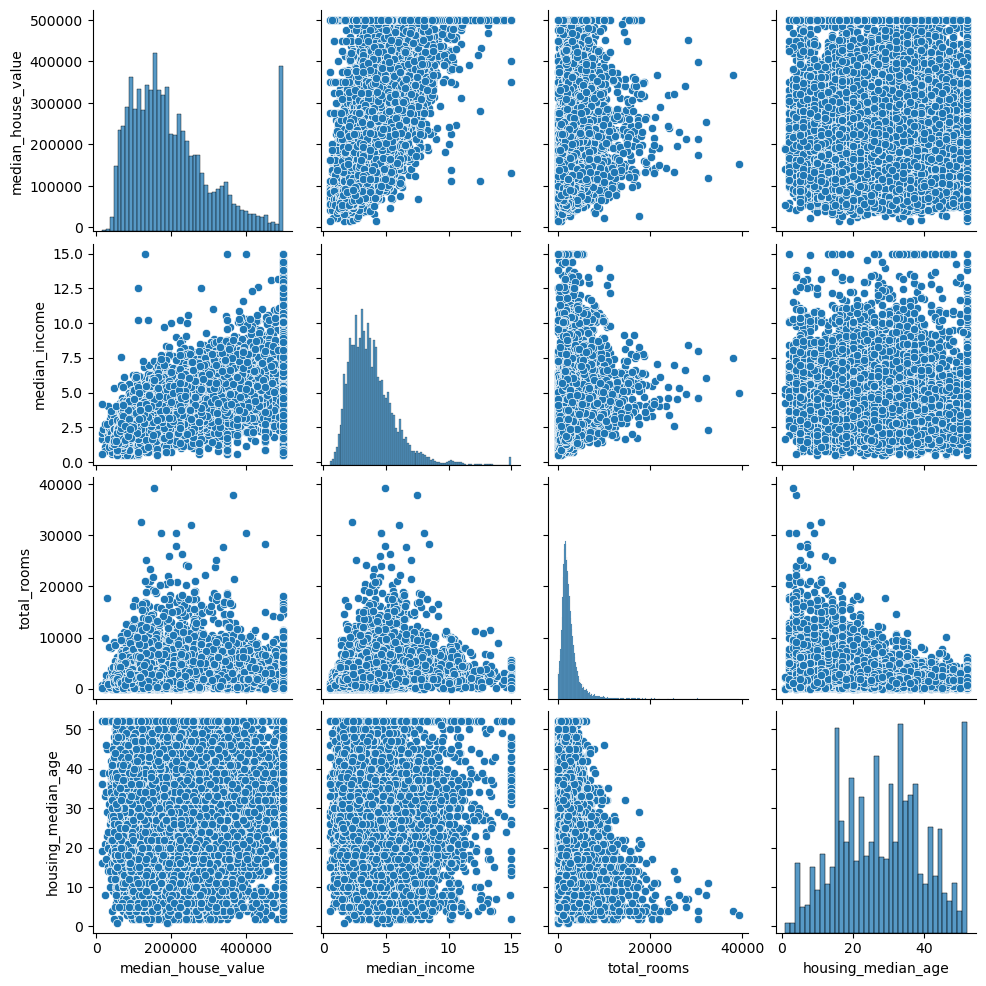

In [16]:
cols = ["median_house_value", "median_income", "total_rooms","housing_median_age"]
sns.pairplot(data=df[cols])

11. Realiza un scatter plot con la libreria sea born de python, el color del grafico puede ser empleado con la columna median_house_value.

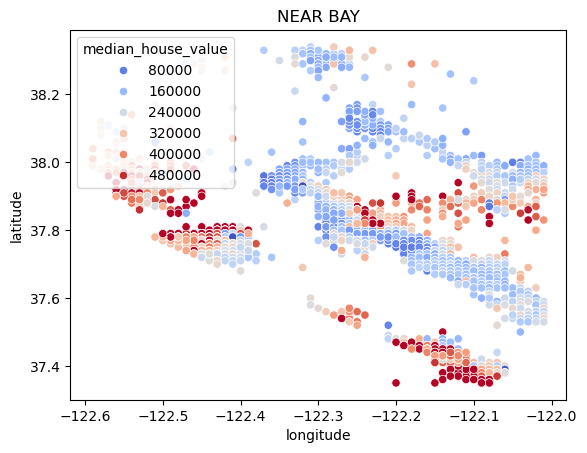

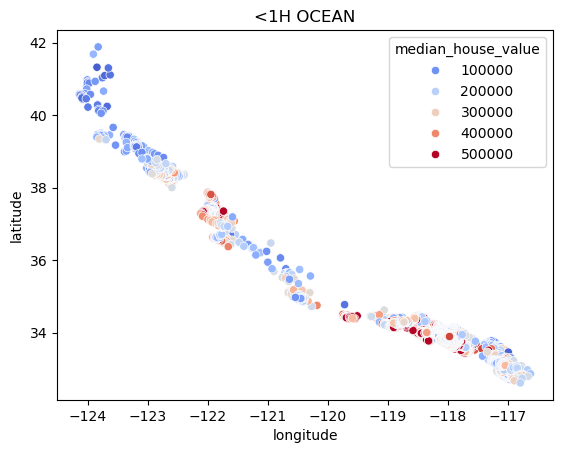

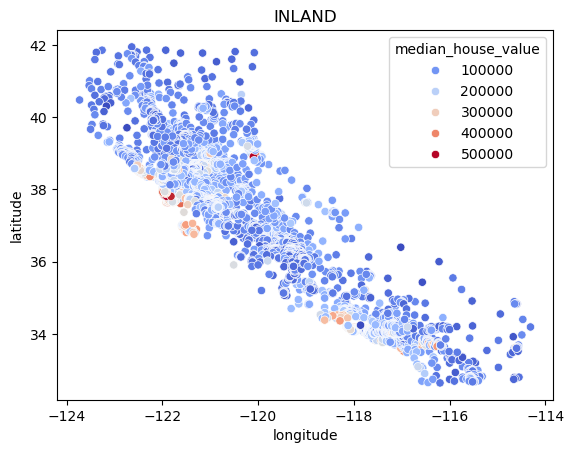

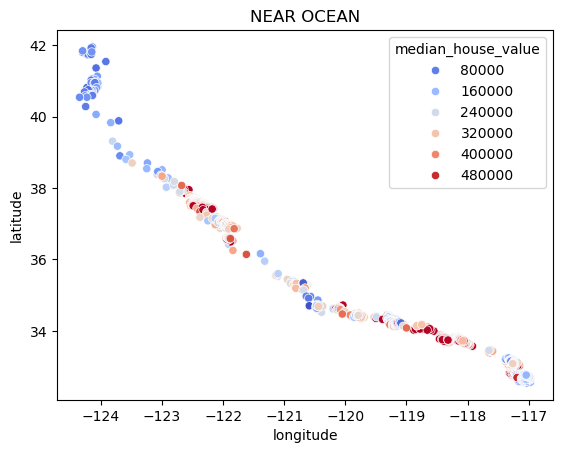

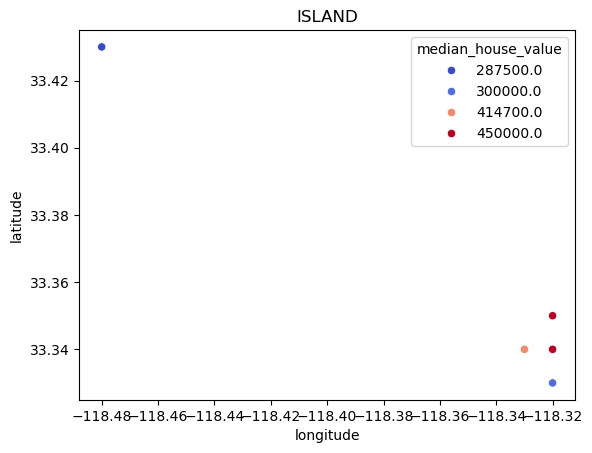

In [17]:
## graficar mapa de calor geografico segun ocean_aproximity
for ol in op_tipos:
    sns.scatterplot(
        data=df[df['ocean_proximity']==ol],
        x='longitude',
        y='latitude',
        hue='median_house_value',
        palette='coolwarm'          # Muestra en rojo los precios altos y azul los bajos
    )
    plt.title(ol)
    
    plt.show()

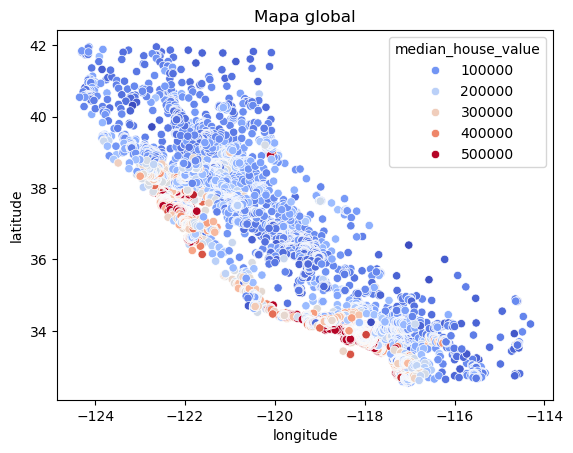

In [18]:
sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='median_house_value',
    palette='coolwarm'          # Muestra en rojo los precios altos y azul los bajos
)
plt.title('Mapa global')
plt.show()

12. ¿Las siguiente linea es adecuada para separar el dataframe en datos de entrenamiento de test?, ¿que pasa en la división de los datos?
```python
from sklearn.model_selection import train_test_split

# ¿Es significativa la muestra que se esta considerando?
train_set, test_set \
    = train_test_split(df, test_size = 0.2, random_state = 42)

print(len(train_set))
print(len(test_set))
```
Se esta considerando 80% de los datos para entrenar, lo cual es razonable para dejar soo el 20% para testear.st_set))

13. División del dataset en grupos:
La siguiente división puede ser realizada basada en la experticie de lo que se esta analizando, y sobre ello se debe tomar una muestra significativa. Una posible solución al problema puede ser el siguiente::

<Axes: >

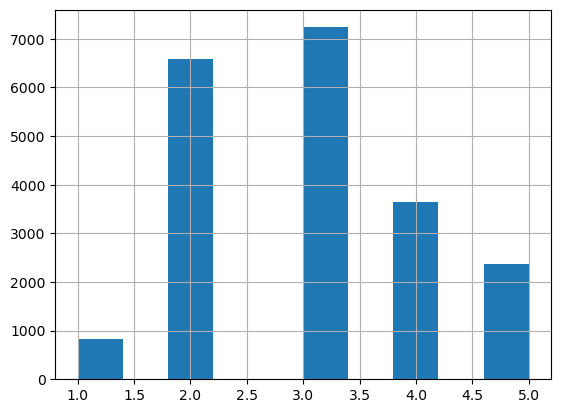

In [19]:
# categorizar la variable continua median_income
df["income_cat"] = pd.cut(df["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])


df.income_cat.hist()

In [20]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits = 1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(df, df["income_cat"]): # test_inddex y train_index son arrays 
  #organizados aleatoriamente de las posiciones de los datos en el el df. El segundo argumento es la columna con base a la cual se estratifica
  strat_train_set = df.loc[train_index]
  strat_test_set = df.loc[test_index]
  print(train_index, ',', test_index)


[12655 15502  2908 ... 19263 19140 19773] , [ 5241 17352  3505 ... 17223 10786  3965]


In [21]:
strat_train_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,INLAND,2
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,NEAR OCEAN,5
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,INLAND,2
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,NEAR OCEAN,2
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,<1H OCEAN,3
...,...,...,...,...,...,...,...,...,...,...,...
15174,-117.07,33.03,14.0,6665.0,1231.0,2026.0,1001.0,5.0900,268500.0,<1H OCEAN,4
12661,-121.42,38.51,15.0,7901.0,1422.0,4769.0,1418.0,2.8139,90400.0,INLAND,2
19263,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797,140400.0,<1H OCEAN,3
19140,-122.70,38.31,14.0,3155.0,580.0,1208.0,501.0,4.1964,258100.0,<1H OCEAN,3


In [22]:
strat_test_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
5241,-118.39,34.12,29.0,6447.0,1012.0,2184.0,960.0,8.2816,500001.0,<1H OCEAN,5
17352,-120.42,34.89,24.0,2020.0,307.0,855.0,283.0,5.0099,162500.0,<1H OCEAN,4
3505,-118.45,34.25,36.0,1453.0,270.0,808.0,275.0,4.3839,204600.0,<1H OCEAN,3
7777,-118.10,33.91,35.0,1653.0,325.0,1072.0,301.0,3.2708,159700.0,<1H OCEAN,3
14155,-117.07,32.77,38.0,3779.0,614.0,1495.0,614.0,4.3529,184000.0,NEAR OCEAN,3
...,...,...,...,...,...,...,...,...,...,...,...
12182,-117.29,33.72,19.0,2248.0,427.0,1207.0,368.0,2.8170,110000.0,<1H OCEAN,2
7275,-118.24,33.99,33.0,885.0,294.0,1270.0,282.0,2.1615,118800.0,<1H OCEAN,2
17223,-119.72,34.44,43.0,1781.0,342.0,663.0,358.0,4.7000,293800.0,<1H OCEAN,4
10786,-117.91,33.63,30.0,2071.0,412.0,1081.0,412.0,4.9125,335700.0,<1H OCEAN,4


Analiza las siguiente lineas de código y saca conclusiones referente a las proporciones del dataset.

In [23]:
df["income_cat"].value_counts() / len(df)     # del total de datos, arroja la fraccion de datos en cada categoria 

income_cat
3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: count, dtype: float64

In [24]:
strat_train_set["income_cat"].value_counts() / len(strat_train_set)     # de los datos de de entrenamiento estratificados, 
#arroja la fraccion de datos en cada categoria 

income_cat
3    0.350594
2    0.318859
4    0.176296
5    0.114462
1    0.039789
Name: count, dtype: float64

In [25]:
train_set, test_set = train_test_split(df, test_size = 0.2, random_state = 7)

In [26]:
train_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
17142,-122.18,37.45,43.0,2061.0,437.0,817.0,385.0,4.4688,460200.0,NEAR BAY,3
5460,-118.47,34.00,37.0,2586.0,765.0,1801.0,737.0,2.6042,305800.0,<1H OCEAN,2
7920,-118.07,33.86,28.0,1789.0,352.0,1347.0,330.0,3.4250,189700.0,<1H OCEAN,3
15846,-122.43,37.75,40.0,4850.0,977.0,1824.0,952.0,5.0519,356100.0,NEAR BAY,4
18194,-122.02,37.38,32.0,1889.0,487.0,1321.0,508.0,3.2574,254400.0,<1H OCEAN,3
...,...,...,...,...,...,...,...,...,...,...,...
13927,-114.60,34.83,46.0,1497.0,309.0,787.0,271.0,2.1908,48100.0,INLAND,2
919,-121.96,37.51,22.0,5811.0,1125.0,3215.0,1086.0,4.4107,223500.0,<1H OCEAN,3
5699,-118.26,34.24,42.0,890.0,179.0,555.0,200.0,4.4821,271900.0,<1H OCEAN,3
10742,-117.91,33.61,38.0,1232.0,178.0,410.0,171.0,11.0750,500001.0,<1H OCEAN,5


In [27]:
test_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
4648,-118.31,34.06,31.0,2827.0,1084.0,3107.0,993.0,2.0278,360000.0,<1H OCEAN,2
8740,-118.31,33.81,30.0,1773.0,356.0,905.0,352.0,4.3056,336000.0,<1H OCEAN,3
162,-122.24,37.81,52.0,2513.0,502.0,1048.0,518.0,3.6750,269900.0,NEAR BAY,3
15735,-122.43,37.78,26.0,3587.0,1034.0,1821.0,936.0,2.6392,287500.0,NEAR BAY,2
18380,-121.86,37.21,23.0,2552.0,305.0,916.0,316.0,9.1974,500001.0,<1H OCEAN,5
...,...,...,...,...,...,...,...,...,...,...,...
1554,-121.98,37.80,16.0,2498.0,330.0,1027.0,343.0,8.1550,343700.0,<1H OCEAN,5
130,-122.21,37.84,34.0,3038.0,490.0,1140.0,496.0,7.0548,325900.0,NEAR BAY,5
537,-122.30,37.77,42.0,2038.0,368.0,2037.0,355.0,2.6447,200000.0,NEAR BAY,2
15982,-122.47,37.76,52.0,2941.0,783.0,1545.0,726.0,2.9899,406500.0,NEAR BAY,2


In [28]:
train_set["income_cat"].value_counts() / len(train_set)    # fracción de datos por categoria sin estratificar

income_cat
3    0.348716
2    0.324188
4    0.173147
5    0.114159
1    0.039789
Name: count, dtype: float64

un comparativo general puede ser estructurado de la siguente forma, analiza los errores:

In [29]:
def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(df, test_size = 0.2, random_state = 42)

compare_props = pd.DataFrame({
    "Overall": income_cat_proportions(df),
    "Stratified": income_cat_proportions(strat_test_set),
    "Random": income_cat_proportions(test_set),
}).sort_index()
compare_props["Rand. %error"] =abs( 100 * compare_props["Random"] / compare_props["Overall"] - 100)
compare_props["Strat. %error"] =abs( 100 * compare_props["Stratified"] / compare_props["Overall"] - 100)

In [30]:
compare_props  # la seleccion estratificaada ha de presentar menos sesgo

,Overall,Stratified,Random,Rand. %error,Strat. %error
income_cat,,,,,
1,0.039826,0.039971,0.040213,0.973236,0.364964
2,0.318847,0.318798,0.324370,1.732260,0.015195
3,0.350581,0.350533,0.358527,2.266446,0.013820
4,0.176308,0.176357,0.167393,5.056334,0.027480
5,0.114438,0.114341,0.109496,4.318374,0.084674


Puedes agregar nuevas variables al dataframe para el análisis, por ejemplo:

In [31]:
df_train = strat_train_set.copy()
df_train["rooms_per_household"] = df_train["total_rooms"]/df_train["households"]
df_train["bedrooms_per_room"] = df_train["total_bedrooms"]/df_train["total_rooms"]
df_train["population_per_household"]=df_train["population"]/df_train["households"]

Lo que sigue son códigos que pueden servir para limpiar los datos.

```Python
df.isnull().sum()


#df_train.dropna(subset=["total_bedrooms"]) #Eliminar los nan
#df_train.drop("total_bedrooms", axis=1)  # Eliminar la columna
median = df_train["total_bedrooms"].median()
q=df_train["total_bedrooms"].fillna(median).copy()


q=pd.DataFrame(q)

q.isnull().sum()
```

**imputer**
Forma automática para tratar los datos (Asegurate de trabajar con las columnas numéricas):

In [32]:
from sklearn.impute import SimpleImputer
#imputer = Imputer(strategy="median")

df_train_num = df_train.drop(["ocean_proximity", "income_cat"], axis=1)  ## elimina la columna ocean_proximity
df_train_num

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,5.485836,0.205784,3.168555
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,6.927083,0.160714,2.623698
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,5.393333,0.191595,2.223333
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,3.886128,0.276505,1.859213
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,6.096552,0.182692,3.167241
...,...,...,...,...,...,...,...,...,...,...,...,...
15174,-117.07,33.03,14.0,6665.0,1231.0,2026.0,1001.0,5.0900,268500.0,6.658342,0.184696,2.023976
12661,-121.42,38.51,15.0,7901.0,1422.0,4769.0,1418.0,2.8139,90400.0,5.571932,0.179977,3.363188
19263,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797,140400.0,4.110465,0.234795,2.662791
19140,-122.70,38.31,14.0,3155.0,580.0,1208.0,501.0,4.1964,258100.0,6.297405,0.183835,2.411178


In [33]:
imp_mean = SimpleImputer( strategy='mean')

imp_mean.fit(df_train_num)

,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [34]:
imp_mean.statistics_    # el promedio de cada columna

array([-1.19575635e+02,  3.56393144e+01,  2.86534036e+01,  2.62253979e+03,
        5.34914639e+02,  1.41968738e+03,  4.97011810e+02,  3.87588428e+00,
        2.07005322e+05,  5.44040595e+00,  2.12872772e-01,  3.09646921e+00])

14. Compara las siguientes variables:
```Python
imp_mean.statistics_
df_train_num.median()
```

In [35]:
comparacion = pd.DataFrame({
    "mean (imputer)": imp_mean.statistics_,
    "median": df_train_num.median()
}, index=df_train_num.columns)

comparacion["diferencia"] = comparacion["mean (imputer)"] - comparacion["median"]
comparacion

,mean (imputer),median,diferencia
longitude,-119.575635,-118.510000,-1.065635
latitude,35.639314,34.260000,1.379314
housing_median_age,28.653404,29.000000,-0.346596
total_rooms,2622.539789,2119.000000,503.539789
total_bedrooms,534.914639,433.000000,101.914639
population,1419.687379,1164.000000,255.687379
households,497.011810,408.000000,89.011810
median_income,3.875884,3.541550,0.334334
median_house_value,207005.322372,179500.000000,27505.322372
rooms_per_household,5.440406,5.232342,0.208064


Constuye la matriz de características:
```Python
X = imp_mean.transform(df)
housing_tr = pd.DataFrame(X, columns=df_train_num.columns)
```

In [36]:
X = imp_mean.transform(df_train_num)
housing_tr = pd.DataFrame(df_train_num)

In [37]:
housing_tr

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,5.485836,0.205784,3.168555
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,6.927083,0.160714,2.623698
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,5.393333,0.191595,2.223333
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,3.886128,0.276505,1.859213
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,6.096552,0.182692,3.167241
...,...,...,...,...,...,...,...,...,...,...,...,...
15174,-117.07,33.03,14.0,6665.0,1231.0,2026.0,1001.0,5.0900,268500.0,6.658342,0.184696,2.023976
12661,-121.42,38.51,15.0,7901.0,1422.0,4769.0,1418.0,2.8139,90400.0,5.571932,0.179977,3.363188
19263,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797,140400.0,4.110465,0.234795,2.662791
19140,-122.70,38.31,14.0,3155.0,580.0,1208.0,501.0,4.1964,258100.0,6.297405,0.183835,2.411178


15. ¿Qué realizan las siguientes lineas de código?

Se crean columnas asociadas a cada categoria de ocean_proximity, y asigna 1 a la proximidad que la casa pertenezcaa y 0 a las demás.


```Python
from sklearn.preprocessing import OneHotEncoder
df_train["ocean_proximity"].unique()
housing_cat=df_train[["ocean_proximity"]]
housing_cat

cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
print(housing_cat_1hot)
print(cat_encoder.categories_)


df_cat_1hot = pd.DataFrame(housing_cat_1hot, columns = cat_encoder.categories_[0])

housing_tr_ = housing_tr.joi

######### 
```n(df_cat_1hot)

In [38]:
from sklearn.preprocessing import OneHotEncoder
df_train["ocean_proximity"].unique()
housing_cat=df_train[["ocean_proximity"]] # columna de datos de ocean_proximity
housing_cat

cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
print(housing_cat_1hot)
print(cat_encoder.categories_)


df_cat_1hot = pd.DataFrame(housing_cat_1hot, columns = cat_encoder.categories_[0])

housing_tr_ = housing_tr.join(df_cat_1hot)

[[0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0.]
 ...
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]]
[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)]


In [39]:
housing_cat

,ocean_proximity
12655,INLAND
15502,NEAR OCEAN
2908,INLAND
14053,NEAR OCEAN
20496,<1H OCEAN
...,...
15174,<1H OCEAN
12661,INLAND
19263,<1H OCEAN
19140,<1H OCEAN


In [40]:
housing_tr_

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,5.485836,0.205784,3.168555,0.0,0.0,0.0,1.0,0.0
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,6.927083,0.160714,2.623698,1.0,0.0,0.0,0.0,0.0
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,5.393333,0.191595,2.223333,1.0,0.0,0.0,0.0,0.0
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,3.886128,0.276505,1.859213,0.0,1.0,0.0,0.0,0.0
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,6.096552,0.182692,3.167241,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15174,-117.07,33.03,14.0,6665.0,1231.0,2026.0,1001.0,5.0900,268500.0,6.658342,0.184696,2.023976,0.0,1.0,0.0,0.0,0.0
12661,-121.42,38.51,15.0,7901.0,1422.0,4769.0,1418.0,2.8139,90400.0,5.571932,0.179977,3.363188,0.0,0.0,0.0,0.0,1.0
19263,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797,140400.0,4.110465,0.234795,2.662791,NaN,NaN,NaN,NaN,NaN
19140,-122.70,38.31,14.0,3155.0,580.0,1208.0,501.0,4.1964,258100.0,6.297405,0.183835,2.411178,NaN,NaN,NaN,NaN,NaN


16. Las variables pueden ser escaladas como sigue:
```Python
cols=["longitude", "latitude",	"housing_median_age",	"total_rooms",\
      "total_bedrooms",	"population",	"households",	"median_income",\
      "<1H OCEAN",	"INLAND",	"ISLAND",	"NEAR BAY", "NEAR OCEAN"]


housing_scale=housing_tr_[cols]
housing_scale
 

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(housing_scale)

X = scaler.transform(housing_scale)


housing_prepared = pd.DataFrame(X, columns = housing_scale.columns)
```

In [41]:
# Normaliza todos los datos
cols=["longitude", "latitude",	"housing_median_age",	"total_rooms",\
      "total_bedrooms",	"population",	"households",	"median_income",\
      "<1H OCEAN",	"INLAND",	"ISLAND",	"NEAR BAY", "NEAR OCEAN"]


housing_scale=housing_tr_[cols]
housing_scale
 

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(housing_scale)

X = scaler.transform(housing_scale)


housing_prepared = pd.DataFrame(X, columns = housing_scale.columns)

housing_prepared

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,0.287849,0.635494,0.549020,0.098362,0.128061,0.062614,0.131441,0.115426,0.0,0.0,0.0,1.0,0.0
1,0.709163,0.058448,0.117647,0.135168,0.137403,0.056392,0.143017,0.402574,1.0,0.0,0.0,0.0,0.0
2,0.528884,0.300744,0.843137,0.041003,0.049613,0.018610,0.055639,0.163798,1.0,0.0,0.0,0.0,0.0
3,0.719124,0.022317,0.450980,0.047591,0.083280,0.025085,0.089806,0.119067,0.0,1.0,0.0,0.0,0.0
4,0.562749,0.184910,0.509804,0.089790,0.103737,0.051403,0.107916,0.275617,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16507,0.725100,0.052072,0.254902,0.169380,0.197970,0.056700,0.186520,0.316554,0.0,1.0,0.0,0.0,0.0
16508,0.291833,0.634431,0.274510,0.200819,0.228737,0.133580,0.264376,0.159584,0.0,0.0,0.0,0.0,1.0
16509,0.162351,0.626993,0.921569,0.017831,0.026418,0.012753,0.031740,0.184811,NaN,NaN,NaN,NaN,NaN
16510,0.164343,0.613177,0.254902,0.080099,0.093106,0.033773,0.093167,0.254928,NaN,NaN,NaN,NaN,NaN


17. Para todos los pasos anteriores, contruye ordenadamente los pasos limpieza, escalamiento de variables, manejo de texto y atributos categóricos para tener el data frame listo para el análisis. Recuerda dividir el data frame en datos de entrenamiento y de test con la correcta estractificación. Genera dos data frame: housing_train, housing_test, cada una, debe tener las caracteristicas y los datos etiquetados.

In [3]:
df1 = pd.read_csv('https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Sesion_07_housing.csv')
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import OneHotEncoder

In [4]:
from sklearn.preprocessing import StandardScaler

# 1. income_cat + split estratificado
df1["income_cat"] = pd.cut(df1["median_income"],
                           bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                           labels=[1, 2, 3, 4, 5])

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(df1, df1["income_cat"]):
    df_train = df1.loc[train_index].copy()
    df_test = df1.loc[test_index].copy()

# 2. Feature engineering
for d in (df_train, df_test):
    d["rooms_per_household"] = d["total_rooms"] / d["households"]
    d["bedrooms_per_room"] = d["total_bedrooms"] / d["total_rooms"]
    d["population_per_household"] = d["population"] / d["households"]
    d["income_per_household"] = d["median_income"] / d["households"]

# 3. Separar target Y ESCALARLO DE UNA VEZ (fit SOLO train)
y_scaler = StandardScaler()

y_train_raw = df_train["median_house_value"].copy()
y_test_raw = df_test["median_house_value"].copy()

y_train = y_scaler.fit_transform(y_train_raw.values.reshape(-1, 1)).ravel()
y_test = y_scaler.transform(y_test_raw.values.reshape(-1, 1)).ravel()
# y_scaler queda guardado -> úsalo después con .inverse_transform() si necesitas
# volver a dólares reales (por ejemplo, para mostrar predicciones legibles)

df_train_num = df_train.drop(["ocean_proximity", "income_cat", "median_house_value"], axis=1)
df_test_num = df_test.drop(["ocean_proximity", "income_cat", "median_house_value"], axis=1)

# 4. Imputer (fit SOLO train)
imp_mean = SimpleImputer(strategy="mean")
imp_mean.fit(df_train_num)

X_train_num = pd.DataFrame(imp_mean.transform(df_train_num),
                            columns=df_train_num.columns, index=df_train_num.index)
X_test_num = pd.DataFrame(imp_mean.transform(df_test_num),
                           columns=df_test_num.columns, index=df_test_num.index)

# 5. One-hot encoder (fit SOLO train)
cat_encoder = OneHotEncoder(sparse_output=False)
cat_encoder.fit(df_train[["ocean_proximity"]])

train_cat_1hot = cat_encoder.transform(df_train[["ocean_proximity"]])
test_cat_1hot = cat_encoder.transform(df_test[["ocean_proximity"]])

df_train_cat = pd.DataFrame(train_cat_1hot, columns=cat_encoder.categories_[0], index=df_train.index)
df_test_cat = pd.DataFrame(test_cat_1hot, columns=cat_encoder.categories_[0], index=df_test.index)

X_train_full = X_train_num.join(df_train_cat)
X_test_full = X_test_num.join(df_test_cat)

# 6. Scaler de X
scaler = MinMaxScaler()
scaler.fit(X_train_full)

X_train_scaled = pd.DataFrame(scaler.transform(X_train_full),
                               columns=X_train_full.columns, index=X_train_full.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_full),
                              columns=X_test_full.columns, index=X_test_full.index)

# 7. Dataframes finales del punto 17, CON EL TARGET YA ESCALADO
housing_train = X_train_scaled.copy()
housing_train["median_house_value"] = y_train  

housing_test = X_test_scaled.copy()
housing_test["median_house_value"] = y_test 

print("housing_train:", housing_train.shape)
print("housing_test:", housing_test.shape)
housing_train.head()

housing_train: (16512, 18)
housing_test: (4128, 18)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,bedrooms_per_room,population_per_household,income_per_household,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,median_house_value
12655,0.287849,0.635494,0.549020,0.098362,0.128061,0.062614,0.131441,0.115426,0.030938,0.117537,0.001993,0.000709,0.0,1.0,0.0,0.0,0.0,-1.166015
15502,0.709163,0.058448,0.117647,0.135168,0.137403,0.056392,0.143017,0.402574,0.041176,0.067460,0.001554,0.002088,0.0,0.0,0.0,0.0,1.0,0.627451
2908,0.528884,0.300744,0.843137,0.041003,0.049613,0.018610,0.055639,0.163798,0.030281,0.101772,0.001232,0.002443,0.0,1.0,0.0,0.0,0.0,-1.074397
14053,0.719124,0.022317,0.450980,0.047591,0.083280,0.025085,0.089806,0.119067,0.019575,0.196117,0.000939,0.001117,0.0,0.0,0.0,0.0,1.0,-0.816829
20496,0.562749,0.184910,0.509804,0.089790,0.103737,0.051403,0.107916,0.275617,0.035276,0.091880,0.001992,0.001955,1.0,0.0,0.0,0.0,0.0,0.270486


In [5]:
from sklearn.linear_model import LinearRegression

X_train = housing_train.drop("median_house_value", axis=1)



model = LinearRegression()
model.fit(X_train, y_train)   # aprende los 17 pesos de una sola vez

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
y_train

array([-1.16601465,  0.62745084, -1.07439665, ..., -0.5756836 ,
        0.44162188, -1.2472608 ], shape=(16512,))

In [7]:
X_test = housing_test.drop("median_house_value", axis=1)


score_test = model.score(X_test, y_test)
print(score_test)

0.6369117296048497


In [8]:
score_train = model.score(X_train, y_train)
print(score_train)

0.6545899825627337


18. ¿que puede concluir respecto al modelo empleado?

Se ajusta parcialmente.

19. ¿El modelo de regresión lineal es valido para lo constrdo?

Es válido para no todas las variables. 

20. ¿qué informacion nos da el e1

El escore da el $$ R^2 = 1- \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2} $$, cuyo valor de 0.6529 indica que el modelo no es completamente lineal.
 
21. ¿Puede ser ajustado a otro modelo?

Desde luego se puede extender a polomios de grado superior.

22. ¿Como puede autmatizar todo el proceso empleando pipelines?
 
Como sigue a continuacion:

In [9]:
#from sklearn.pipeline import Pipeline
#from sklearn.compose import ColumnTransformer
#from sklearn.impute import SimpleImputer
#from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
#
#num_cols = ["longitude", "latitude", "housing_median_age", "total_rooms",
#            "total_bedrooms", "population", "households", "median_income"]
#cat_cols = ["ocean_proximity"]
#
#num_pipeline = Pipeline([
#    ("imputer", SimpleImputer(strategy="mean")),  ## llenar datos nan
#    ("scaler", MinMaxScaler()),  ## escalar variables
#])
#
#full_pipeline = ColumnTransformer([
#    ("num", num_pipeline, num_cols),        
#    ("cat", OneHotEncoder(), cat_cols),   ## one hot encodear variables categoricas
#])
#
## Un solo fit, con TODO el proceso encadenado:
#X_train = full_pipeline.fit_transform(df_train)
#X_test = full_pipeline.transform(df_test)

23. La regresión lineal de los puntos 17 a 20 usa todas las variables preparadas. Construye ahora un modelo con muy pocas variables, obtenidas a partir de la matriz de covarianzas, y compáralo con ella.

Parte de la misma división estratificada del punto 13 (división del dataset) y de las mismas variables numéricas del punto 17. Calcula las componentes principales con PCA y decide cuántas conservar.

Relaciona las cargas de las componentes con lo que viste en la matriz de correlación (punto 9) y en el pairplot (punto 10). ¿Qué grupos de variables resumen?

Revisa las variables creadas en el punto 13 (nuevas variables), como rooms_per_household o bedrooms_per_room. ¿Aportan información que las componentes no capturan?

En el punto 16 se escaló con MinMaxScaler. ¿Es la elección adecuada para PCA? Justifica tu decisión.
Ajusta tu modelo reducido y compara su score con el de la regresión analizada en el punto 20. 

¿Cuánto se pierde por usar tan pocas variables?

Con un test de permutaciones, argumenta si tu modelo reducido captura algo real.

Compara los coeficientes de ambos modelos. ¿Cuál es más fácil de interpretar y por qué?

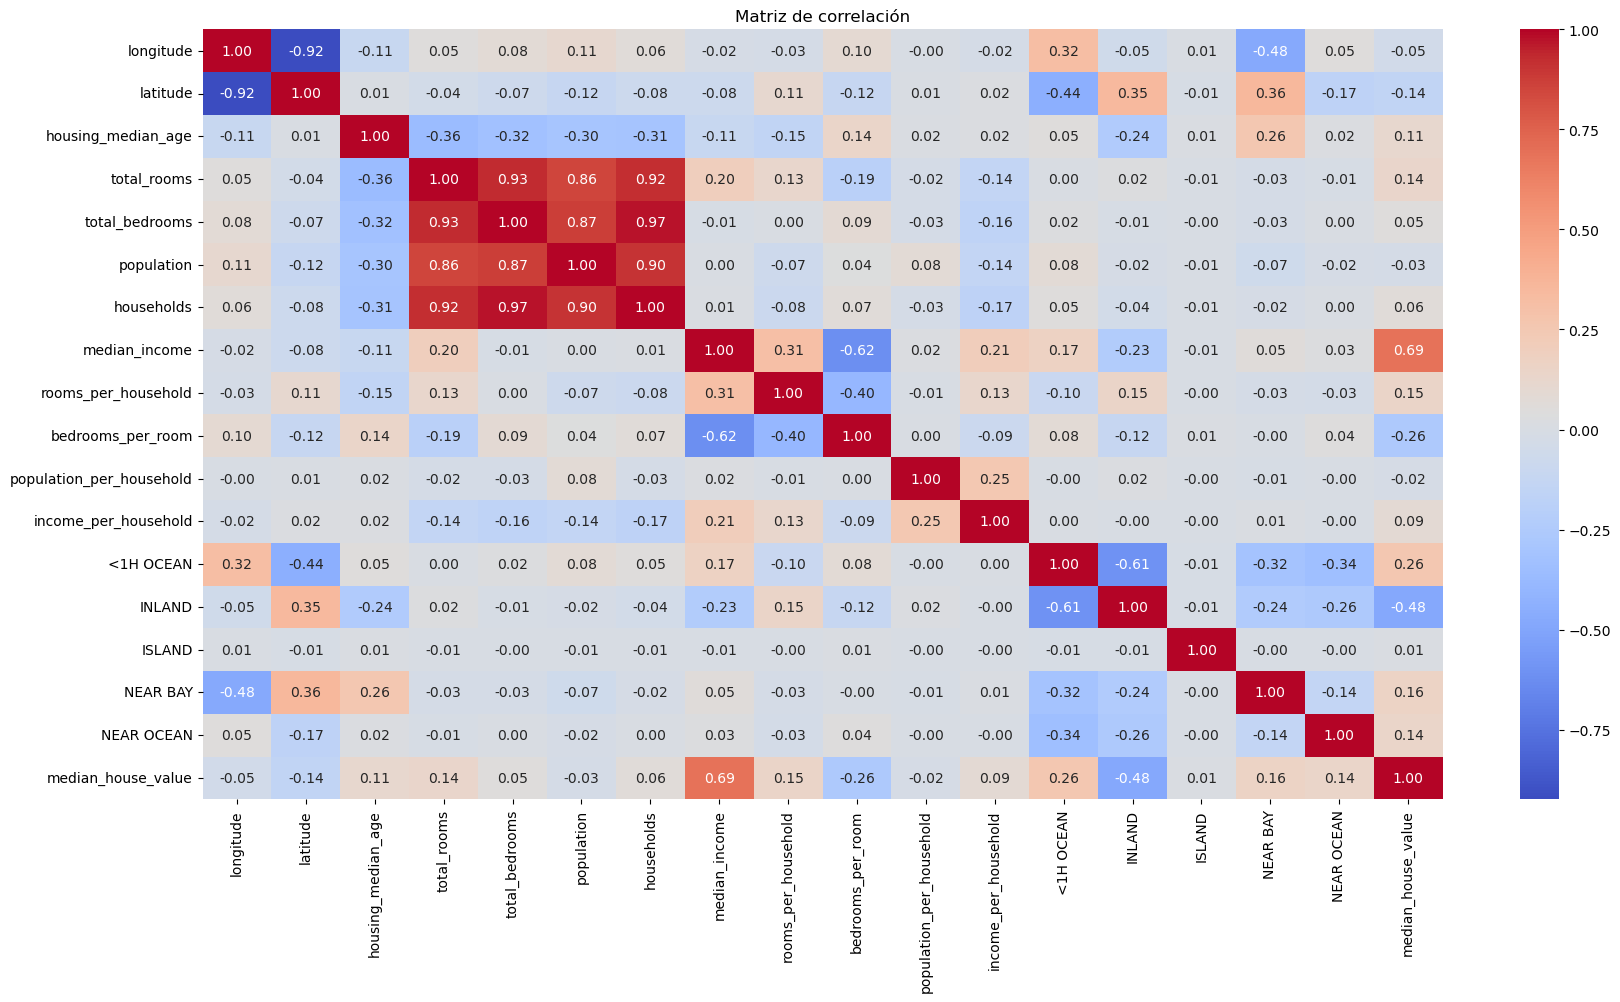

In [10]:
# Reevaluacion de la matriz de correlacion: las variables de densidad no presentan correlaciones mucho mas fuertes que
# las otras variables numericas, exceptuando la housing_media_age. Todas estas variables numéricas restantes sí parecen 
#susceptibles de reducción dimensional.
# total_rooms, total_bedrooms, population y households se han de reducir en una sola dimension.

plt.figure(figsize=(20,10))
sns.heatmap(housing_train.corr(method='pearson'), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de correlación')
plt.show()

# total_rooms, total_bedrooms, population, households

In [11]:
from sklearn.decomposition import PCA

pca = PCA()      # ajusta el número según cuánta varianza quieras conservar
pca.fit(X_train)                # fit SOLO con train

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [12]:
print(pca.explained_variance_ratio_)     ## elementos de laa matriz de correlacion diagonalizada

[4.54664245e-01 2.20638312e-01 1.64081060e-01 6.55696650e-02
 5.72809542e-02 2.04158005e-02 1.22795321e-02 2.29181089e-03
 1.44954354e-03 3.63473761e-04 2.77538676e-04 2.05232366e-04
 1.75383824e-04 1.48077756e-04 9.00978800e-05 6.92723557e-05
 0.00000000e+00]


In [13]:
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)
print(varianza_acumulada)

[0.45466425 0.67530256 0.83938362 0.90495328 0.96223424 0.98265004
 0.99492957 0.99722138 0.99867092 0.9990344  0.99931194 0.99951717
 0.99969255 0.99984063 0.99993073 1.         1.        ]


Conservo solo los primeros componentes (96 porciento de la información).

In [14]:
pca_reducido = PCA(n_components=5)
pca_reducido.fit(X_train)

X_train_reducido = pca_reducido.transform(X_train)
X_test_reducido = pca_reducido.transform(X_test)

In [15]:
model_reducido = LinearRegression()
model_reducido.fit(X_train_reducido, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
score_test_red = model_reducido.score(X_test_reducido, y_test)
print(score_test_red)    ### score del modelo reducido

0.26895238215902617


In [17]:
import numpy as np

# --- Paso 0: configuración ---
n_permutaciones = 1000   # cuántas veces vamos a barajar (más = más preciso, pero más lento)

# --- Paso 1: calcular las predicciones de cada modelo sobre TEST ---
# (ambos modelos ya están entrenados, aquí solo evaluamos)
pred_completo = model.predict(X_test)                  # predicciones del modelo con las 17 columnas
pred_reducido = model_reducido.predict(X_test_reducido) # predicciones del modelo con 5 componentes PCA

# --- Paso 2: calcular el error de cada predicción individual (error cuadrático) ---
error_completo = (y_test - pred_completo) ** 2    # un error por cada fila de test, modelo completo
error_reducido = (y_test - pred_reducido) ** 2    # un error por cada fila de test, modelo reducido

# --- Paso 3: la diferencia REAL que observamos entre los dos modelos ---
# si model_reducido es peor, este número va a ser positivo
diff_observada = error_reducido.mean() - error_completo.mean()

# --- Paso 4: preparar la "bolsa" donde vamos a mezclar los errores de ambos modelos ---
# juntamos TODOS los errores (los de completo y los de reducido) en un solo array
todos_errores = np.concatenate([error_completo, error_reducido])
n = len(error_completo)   # cuántas filas tiene cada grupo (deben ser iguales)

# --- Paso 5: el loop de permutaciones ---
diffs_permutadas = []   # aquí guardamos la diferencia de cada barajada

for _ in range(n_permutaciones):
    np.random.shuffle(todos_errores)      # baraja TODOS los errores juntos, al azar
    grupo1 = todos_errores[:n]            # toma los primeros n como si fueran "grupo completo"
    grupo2 = todos_errores[n:]            # el resto como si fueran "grupo reducido"
    # OJO: como ya se barajó, grupo1 y grupo2 ya NO corresponden a los modelos reales,
    # es una mezcla simulada bajo el supuesto de que "no importa de qué modelo viene cada error"
    diffs_permutadas.append(grupo2.mean() - grupo1.mean())

diffs_permutadas = np.array(diffs_permutadas)   # convertir la lista a array de numpy

# --- Paso 6: calcular el p-value ---
# cuenta en cuántas de las 1000 mezclas al azar la diferencia fue
# igual o más extrema (en valor absoluto) que la diferencia real observada
p_value = np.mean(np.abs(diffs_permutadas) >= np.abs(diff_observada))

print("Diferencia observada:", diff_observada)
print("p-value:", p_value)

Diferencia observada: 0.35826062935940345
p-value: 0.0


Las variables creadas en Feature engineering parecen tener información propia por que no están fuertemente correlacionadas a otras variables. El uso de MinMaxScaler es adecuado porque al tener todas las variables en la misma escala, el análisis PCA no le da más peso a unas variables por sobre otras por tener escalas de valores mayores. Al hacer la reducción dimensional, se ha obtenido un R2 de 0.269, lo cual es apreciable menor al score de 0.637 obtenido en el testeo, de modo que se ha perdido una capacidad d epredictibilidad apreciable tras la reducción, lo cual fue verificado por el test de permutación.

En el test de permutaciones, se usó como estadístico a la varianza. La hipótesis nula es H_0: No hay diferencia entre un modelo y otro, la cual fue es rechazada por que el p valor dio cero.

**24**. Responde con evidencia la pregunta del punto 21, "¿Puede ser ajustado a otro modelo?", extendiendo la regresión lineal del punto 17 en dos pasos.

-Aumenta su complejidad, por ejemplo con términos polinomiales, hasta que sobreajuste. Muéstralo comparando su error con el de la regresión original.
    
-Controla el sobreajuste con Ridge (L2) y con Lasso (L1). Analiza cómo cambia el paso de gradiente descendente con el término L2.
    
-Grafica cómo evolucionan los coeficientes y el error al variar la intensidad de la regularización y explica las diferencias entre L1 y L2.
    
-Observa qué hace cada método con las variables colineales que identificaste en el punto 23.

-Organiza todo en un Pipeline, retomando lo planteado en el punto 22. Selecciona los hiperparámetros sin tocar el conjunto de test.

In [18]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
import matplotlib.cm as cm

In [26]:
grados = [1, 2, 3]   # grado 1 = igual a la regresión lineal normal
resultados_poly = []
 
mse_base = None   # aquí se guarda el error cuadratico del grado 1
 
for grado in grados:
    ## generar array con potencias de hasta el grado dado
    poly = PolynomialFeatures(degree=grado, include_bias=False)  
    X_train_poly = poly.fit_transform(X_train)  
    X_test_poly = poly.transform(X_test)

    ## entrenar modelo
    modelo_poly = LinearRegression()
    modelo_poly.fit(X_train_poly, y_train)

    ## score del testeo
    score_train = modelo_poly.score(X_train_poly, y_train)
    score_test = modelo_poly.score(X_test_poly, y_test)
 
    # predeccion
    pred_train = modelo_poly.predict(X_train_poly)
    pred_test = modelo_poly.predict(X_test_poly)

    # calcular error cuadratico entre los datos y el modelo
    mse_train = mean_squared_error(y_train, pred_train)
    mse_test = mean_squared_error(y_test, pred_test)
 
    if grado == 1:
        mse_base = mse_test   # el modelo lineal original es la referencia
 
    # diferencia absoluta entre los errores cuadratico de la prediccion del polinomio y el modelo lineal
    diferencia_mse = mse_test - mse_base 

    
    resultados_poly.append({
        "grado": grado,
        "n_features": X_train_poly.shape[1],
        "score_train": score_train,
        "score_test": score_test,
        "mse_train": mse_train,
        "mse_test": mse_test,
        "diferencia_vs_grado1": diferencia_mse
    })
 
    print(f"Grado {grado}: n_features={X_train_poly.shape[1]}, "
          f"score_train={score_train:.4f}, score_test={score_test:.4f}, "
          f"MSE_test={mse_test:.4f}")
 
df_poly = pd.DataFrame(resultados_poly)
print(df_poly)

Grado 1: n_features=17, score_train=0.6546, score_test=0.6369, MSE_test=0.3535
Grado 2: n_features=170, score_train=0.7342, score_test=-5.7803, MSE_test=6.6016
Grado 3: n_features=1139, score_train=0.8050, score_test=-284.5895, MSE_test=278.0619
   grado  n_features  score_train  score_test  mse_train    mse_test  \
0      1          17     0.654590    0.636912   0.345410    0.353518   
1      2         170     0.734159   -5.780318   0.265841    6.601601   
2      3        1139     0.805015 -284.589509   0.194985  278.061905   

   diferencia_vs_grado1  
0              0.000000  
1              6.248083  
2            277.708387  


Los modelos no lineales explotan muy rápido.

In [20]:
# ============================================================
# PARTE 2: Controlar el sobreajuste con Ridge (L2) y Lasso (L1)

# uso como ejemplo el polinomio de grado 2
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly2 = poly2.fit_transform(X_train)
X_test_poly2 = poly2.transform(X_test)
 
# Ridge (L2)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_poly2, y_train)
print("Ridge  -> train:", ridge.score(X_train_poly2, y_train),
      " test:", ridge.score(X_test_poly2, y_test))
 
# Lasso (L1)
lasso = Lasso(alpha=0.01, max_iter=10000)
lasso.fit(X_train_poly2, y_train)
print("Lasso  -> train:", lasso.score(X_train_poly2, y_train),
      " test:", lasso.score(X_test_poly2, y_test))
 
# Nota conceptual sobre el gradiente descendente con L2:
# La función de costo pasa de ser solo el MSE a ser MSE + alpha * sum(w_i^2).
# Al derivar para el paso de gradiente, aparece un término extra "-2*alpha*w_i"
# que EMPUJA los coeficientes hacia cero en cada actualización, proporcional
# a su propio tamaño (coeficientes grandes se reducen más). Esto evita que
# ningún peso crezca sin control, que es justo lo que causa el sobreajuste.

Ridge  -> train: 0.696373796239327  test: 0.6951716873325191
Lasso  -> train: 0.5878473806717651  test: 0.592102266311118


C:\Users\Asus\AppData\Local\Temp\ipykernel_29276\1143728379.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", 10)


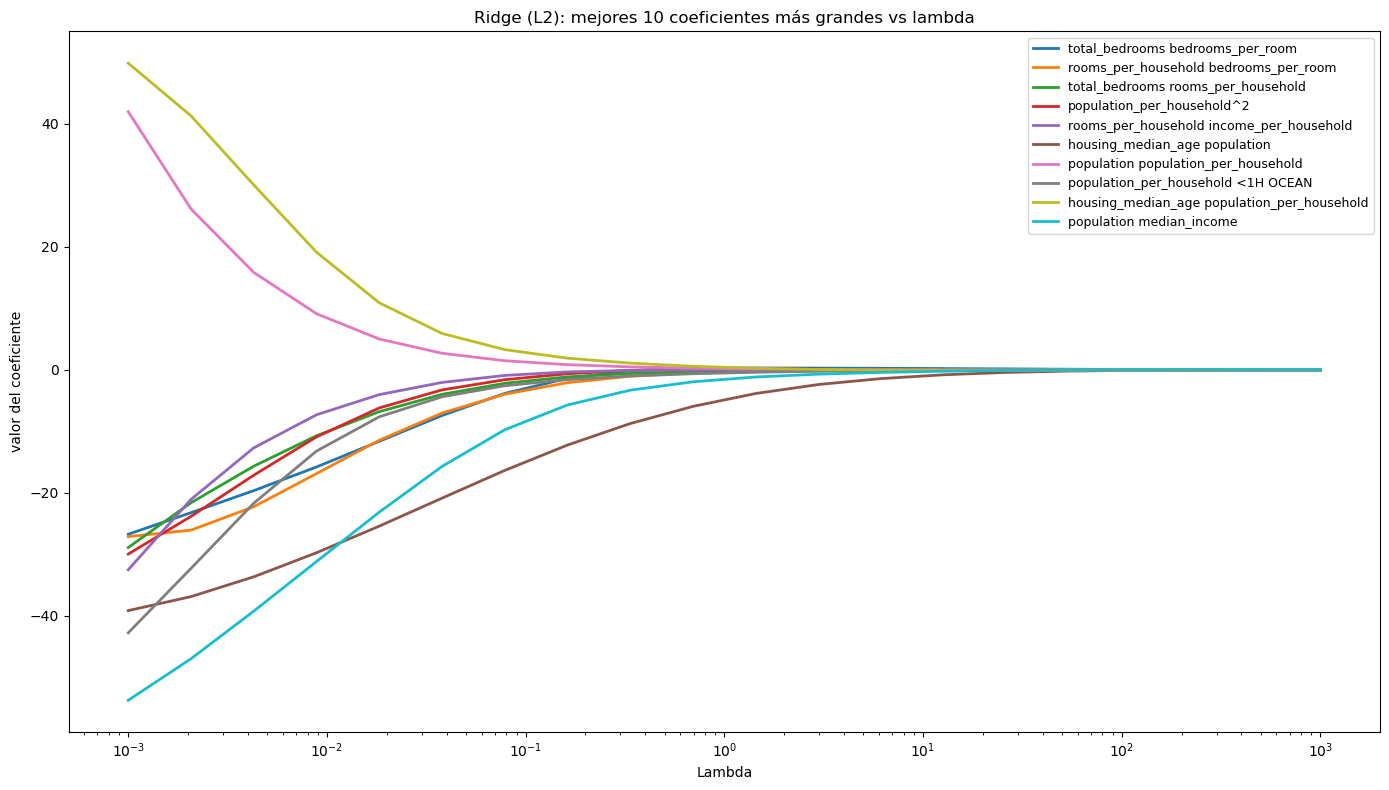

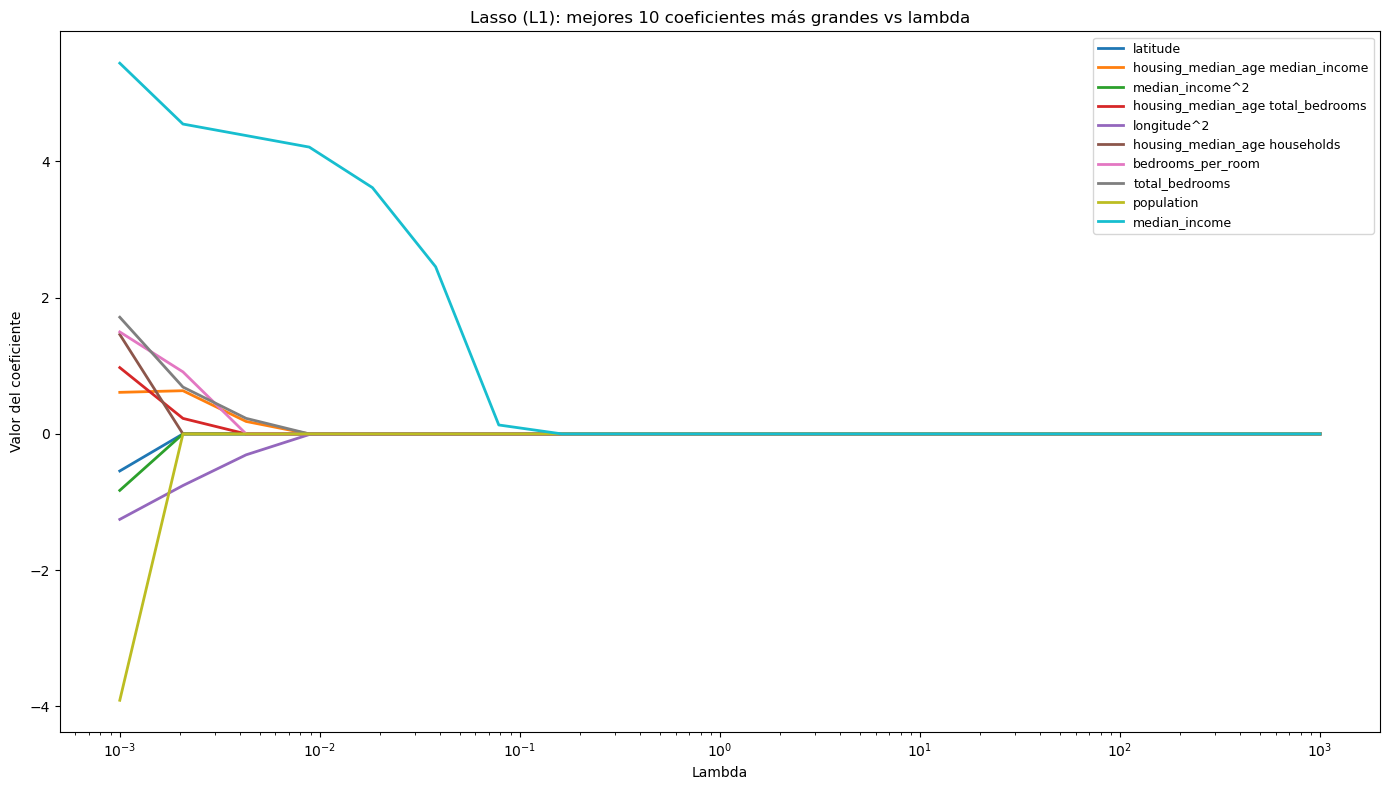

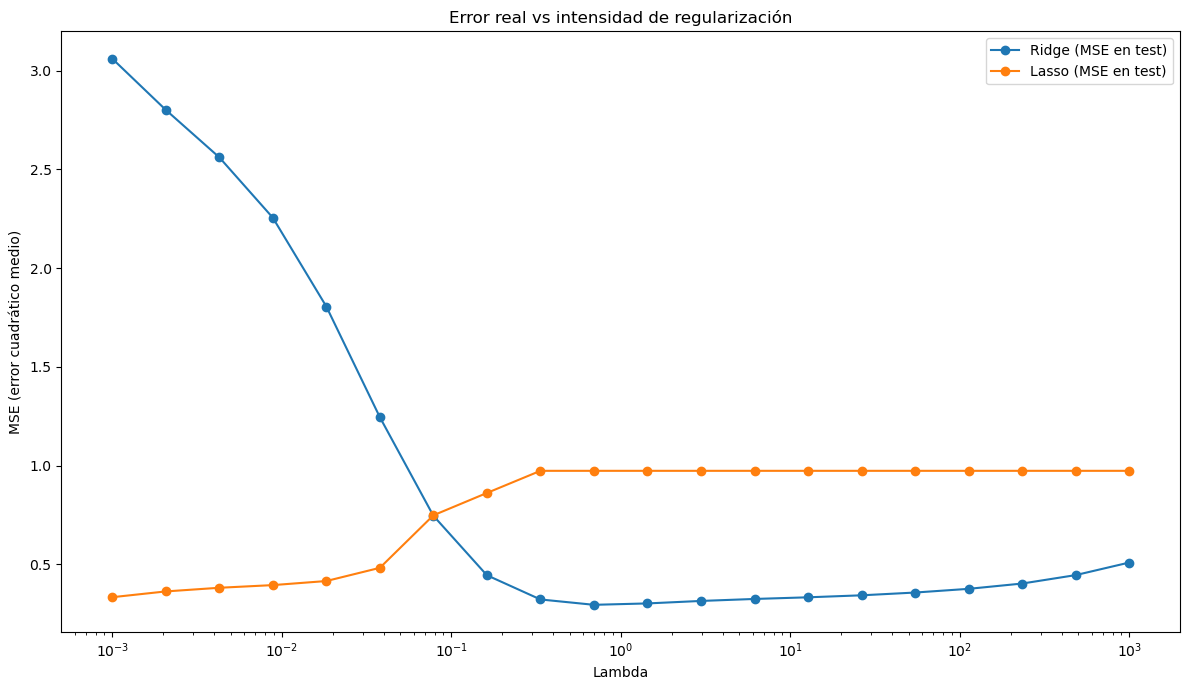

In [21]:
# PARTE 3: graficar coeficientes en función del parámetro de regularización
landas = np.logspace(-3, 3, 20)

## listas para agregar los coeficientes y los errores de los modelos ridge y lasso respectivamente
coefs_ridge, coefs_lasso = [], []
mse_ridge, mse_lasso = [], []
 
for landa in landas:   ## barrido paramétrico sobre cada 
    r = Ridge(alpha=landa).fit(X_train_poly2, y_train)      ## entrenar ridge
    l = Lasso(alpha=landa, max_iter=50000).fit(X_train_poly2, y_train)     ## entrenar lasso

    ## extraer listas de coeficientes de ambos modelos
    coefs_ridge.append(r.coef_) 
    coefs_lasso.append(l.coef_)

    ## testear predicción
    pred_r = r.predict(X_test_poly2)
    pred_l = l.predict(X_test_poly2)

    ## agregar error 
    mse_ridge.append(mean_squared_error(y_test, pred_r))
    mse_lasso.append(mean_squared_error(y_test, pred_l))

    ## iniciar nuevo ciclo // terminar



## convertir listas a rrays los arreglos de coeficientes
coefs_ridge = np.array(coefs_ridge)
coefs_lasso = np.array(coefs_lasso)
 
feature_names = poly2.get_feature_names_out(X_train.columns)
 
# Top 10 features con coeficiente más grande en valor absoluto (usando alpha más chico)
top_ridge = np.argsort(np.abs(coefs_ridge[0]))[-10:]
top_lasso = np.argsort(np.abs(coefs_lasso[0]))[-10:]
 
cmap = cm.get_cmap("tab10", 10)
 

# Gráfica 1: Ridge - mejores 10 coeficientes
plt.figure(figsize=(14, 8))
for pos, i in enumerate(top_ridge):
    plt.plot(landas, coefs_ridge[:, i], label=feature_names[i], color=cmap(pos), linewidth=2)
plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("valor del coeficiente")
plt.title("Ridge (L2): mejores 10 coeficientes más grandes vs lambda")
plt.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.savefig("ridge_top10.png", dpi=150, bbox_inches="tight")
plt.show()
 
# ============================================================
# Gráfica 2: Lasso - mejores 10 coeficientes
plt.figure(figsize=(14, 8))
for pos, i in enumerate(top_lasso):
    plt.plot(landas, coefs_lasso[:, i], label=feature_names[i], color=cmap(pos), linewidth=2)
plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("Valor del coeficiente")
plt.title("Lasso (L1): mejores 10 coeficientes más grandes vs lambda")
plt.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.savefig("lasso_top10.png", dpi=150, bbox_inches="tight")
plt.show()
 
# ============================================================
# Gráfica 3: curva de error real (MSE) vs alpha
# ============================================================
plt.figure(figsize=(12, 7))
plt.plot(landas, mse_ridge, marker='o', label="Ridge (MSE en test)")
plt.plot(landas, mse_lasso, marker='o', label="Lasso (MSE en test)")
plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("MSE (error cuadrático medio)")
plt.title("Error real vs intensidad de regularización")
plt.legend()
plt.tight_layout()
plt.savefig("error_vs_lambda.png", dpi=150, bbox_inches="tight")
plt.show()
 

El error de Lasso es menor cuanto menor sea su parámetro, mientras que Ridge tiene un mínimo de error alrededor de uno.

C:\Users\Asus\AppData\Local\Temp\ipykernel_29276\794295300.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", len(indices))


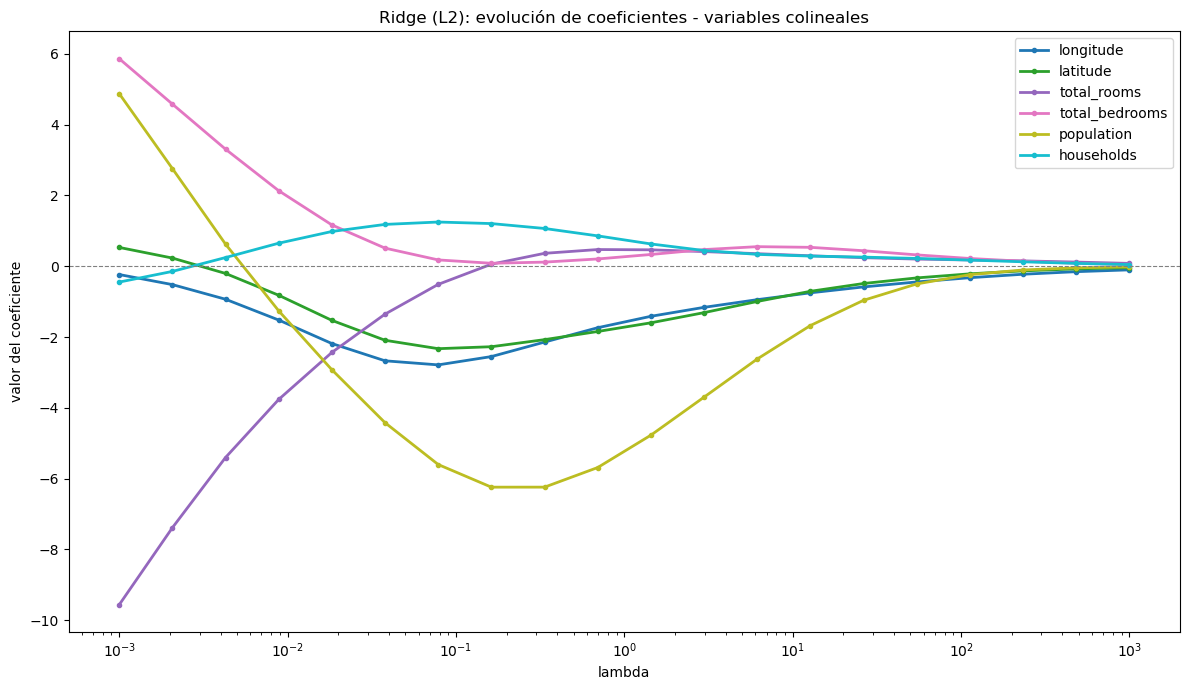

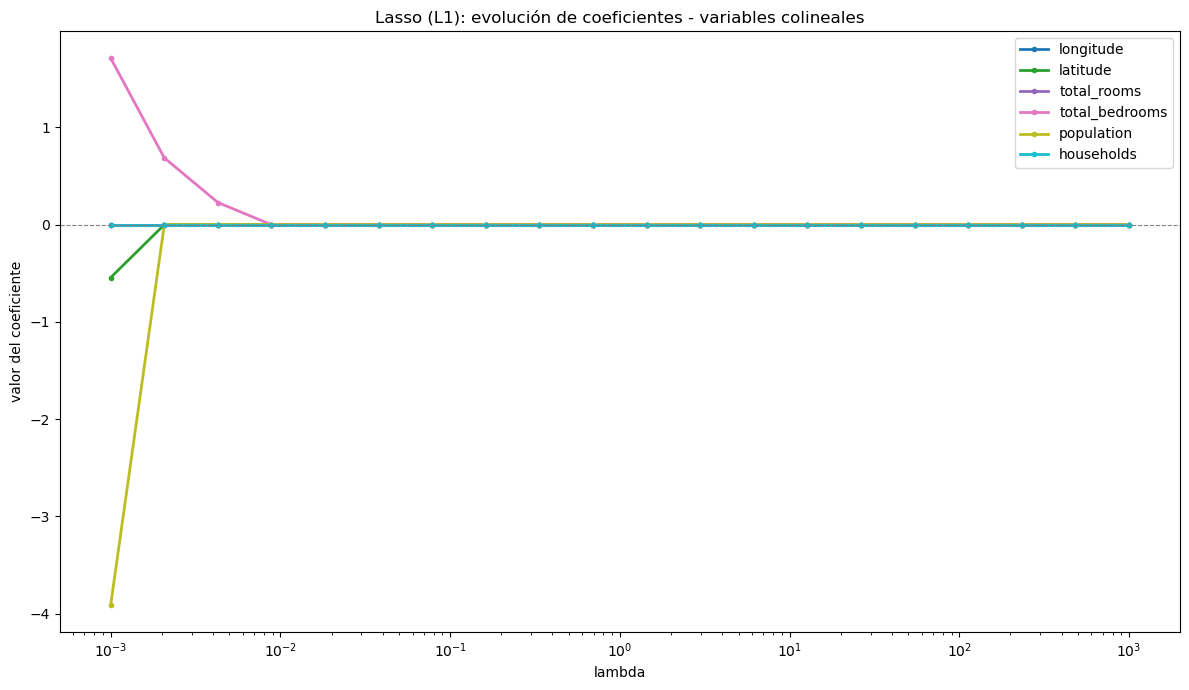

In [22]:
# PARTE 4: Variables colineales del punto 23 en función del parámetro de regularización
## había identificado latitud y altitud como colineales, y de otro lado a total_rooms, total_bedrooms, population y households como colineales.
caracteristicas_colineales = ["longitude", "latitude", "total_rooms",
                            "total_bedrooms", "population", "households"]
 
# Busca el índice EXACTO de cada una en feature_names (el término de grado 1,
# no sus combinaciones como "longitude latitude" o "total_rooms^2")
indices = [np.where(feature_names == c)[0][0] for c in caracteristicas_colineales]
 
cmap = cm.get_cmap("tab10", len(indices))
 
# ============================================================
# Gráfica Ridge
# ============================================================
plt.figure(figsize=(12, 7))
for pos, i in enumerate(indices):
    plt.plot(landas, coefs_ridge[:, i], label=feature_names[i], color=cmap(pos), linewidth=2, marker='o', markersize=3)
plt.xscale("log")
plt.xlabel("lambda")
plt.ylabel("valor del coeficiente")
plt.title("Ridge (L2): evolución de coeficientes - variables colineales")
plt.legend(loc="best", fontsize=10)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.savefig("ridge_features_especificas.png", dpi=150, bbox_inches="tight")
plt.show()
 
# ============================================================
# Gráfica Lasso
# ============================================================
plt.figure(figsize=(12, 7))
for pos, i in enumerate(indices):
    plt.plot(landas, coefs_lasso[:, i], label=feature_names[i], color=cmap(pos), linewidth=2, marker='o', markersize=3)
plt.xscale("log")
plt.xlabel("lambda")
plt.ylabel("valor del coeficiente")
plt.title("Lasso (L1): evolución de coeficientes - variables colineales")
plt.legend(loc="best", fontsize=10)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.savefig("lasso_features_especificas.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
# PARTE 5: pipeline
pipe_ridge = Pipeline([
    ("poly", PolynomialFeatures(include_bias=False)),
    ("ridge", Ridge()),
])
 
param_grid_ridge = {
    "poly__degree": [1, 2],
    "ridge__alpha": np.logspace(-3, 3, 10),
}
 
# GridSearchCV hace su propia validación cruzada DENTRO de train (cv=5 folds),
# nunca mira X_test/y_test durante la búsqueda -> hiperparámetros elegidos sin leakage
grid_ridge = GridSearchCV(pipe_ridge, param_grid_ridge, cv=5, scoring="r2", n_jobs=-1)
grid_ridge.fit(X_train, y_train)
 
print("=== RIDGE ===")
print("Mejores hiperparámetros:", grid_ridge.best_params_)
print("Mejor score en validación cruzada (train):", grid_ridge.best_score_)
 
mejor_ridge = grid_ridge.best_estimator_
score_test_ridge = mejor_ridge.score(X_test, y_test)   # SOLO AHORA se toca test
print("Score final en test:", score_test_ridge)
 
# ============================================================
# Pipeline para LASSO: mismo esquema
# ============================================================
pipe_lasso = Pipeline([
    ("poly", PolynomialFeatures(include_bias=False)),
    ("lasso", Lasso(max_iter=50000)),
])
 
param_grid_lasso = {
    "poly__degree": [1, 2],
    "lasso__alpha": np.logspace(-3, 1, 10),   # Lasso necesita alphas más chicos para no anular todo
}
 
grid_lasso = GridSearchCV(pipe_lasso, param_grid_lasso, cv=5, scoring="r2", n_jobs=-1)
grid_lasso.fit(X_train, y_train)
 
print("\n=== LASSO ===")
print("Mejores hiperparámetros:", grid_lasso.best_params_)
print("Mejor score en validación cruzada (train):", grid_lasso.best_score_)
 
mejor_lasso = grid_lasso.best_estimator_
score_test_lasso = mejor_lasso.score(X_test, y_test)   # SOLO AHORA se toca test
print("Score final en test:", score_test_lasso)
 
# ============================================================
# Guarda estos dos modelos para reusarlos en el punto 25
# ============================================================
# mejor_ridge y mejor_lasso ya son los Pipelines completos (poly + modelo)
# entrenados con los mejores hiperparámetros encontrados -- úsalos directo
# en el punto 25 para comparar contra la regresión del punto 17 y el PCA.

=== RIDGE ===
Mejores hiperparámetros: {'poly__degree': 2, 'ridge__alpha': np.float64(0.1)}
Mejor score en validación cruzada (train): 0.7069175839007624
Score final en test: 0.361345400462565

=== LASSO ===
Mejores hiperparámetros: {'lasso__alpha': np.float64(0.001), 'poly__degree': 2}
Mejor score en validación cruzada (train): 0.6504345993823917
Score final en test: 0.6573175800795688


25. Evalúa en housing_test, con la misma partición y la misma métrica, cuatro modelos:

-la regresión lineal del punto 17,

-el modelo reducido del punto 23,

-el mejor Ridge del punto 24,

-el mejor Lasso del punto 24.

Después responde:

Con bootstrap, determina si las diferencias de desempeño frente a la regresión del punto 17 son estadísticamente significativas.
¿Las variables que conserva Lasso se relacionan con las que destacó PCA? ¿Por qué?
Vuelve a responder los puntos 18 a 20 a la luz de esta comparación. ¿Cambió tu conclusión sobre la regresión lineal original?
¿Cuánto desempeño se pierde a cambio de interpretabilidad? ¿Qué modelo presentarías a alguien que no es especialista, y por qué?

In [28]:
from sklearn.metrics import r2_score
# ============================================================
# PASO 1: evaluar los 4 modelos en housing_test, misma métrica (R²)
# ============================================================
score_17 = model.score(X_test, y_test)
score_pca = model_reducido.score(X_test_reducido, y_test)
score_ridge = mejor_ridge.score(X_test, y_test)
score_lasso = mejor_lasso.score(X_test, y_test)
 
tabla_resultados = pd.DataFrame({
    "Modelo": ["Regresión lineal (17)", "PCA reducido (23)", "Ridge (24)", "Lasso (24)"],
    "R2_test": [score_17, score_pca, score_ridge, score_lasso],
})
print(tabla_resultados)
 
# ============================================================
# PASO 2: Bootstrap -- diferencias de desempeño vs la regresión del punto 17
# ============================================================
n_bootstrap = 1000
 
pred_17 = model.predict(X_test)
pred_pca = model_reducido.predict(X_test_reducido)
pred_ridge = mejor_ridge.predict(X_test)
pred_lasso = mejor_lasso.predict(X_test)
 
y_test_arr = np.asarray(y_test)
 
def bootstrap_diff_r2(y_true, pred_base, pred_otro, n_bootstrap=1000):
    n = len(y_true)
    diffs = []
    for _ in range(n_bootstrap):
        idx = np.random.choice(n, size=n, replace=True)
        r2_base = r2_score(y_true[idx], pred_base[idx])
        r2_otro = r2_score(y_true[idx], pred_otro[idx])
        diffs.append(r2_otro - r2_base)
    return np.array(diffs)
 
resultados_bootstrap = {}
 
for nombre, pred in [("PCA (23)", pred_pca), ("Ridge (24)", pred_ridge), ("Lasso (24)", pred_lasso)]:
    diffs = bootstrap_diff_r2(y_test_arr, pred_17, pred, n_bootstrap=n_bootstrap)
    ic_95 = np.percentile(diffs, [2.5, 97.5])
    significativo = not (ic_95[0] <= 0 <= ic_95[1])
 
    resultados_bootstrap[nombre] = {
        "diferencia_promedio": diffs.mean(),
        "IC_95%": ic_95,
        "significativo": significativo,
    }
 
    print(f"\n{nombre} vs Regresión (17):")
    print(f"  Diferencia promedio en R²: {diffs.mean():.4f}")
    print(f"  Intervalo de confianza 95%: [{ic_95[0]:.4f}, {ic_95[1]:.4f}]")
    print(f"  ¿Diferencia significativa? {'Sí' if significativo else 'No'}")
 
# ============================================================
# PASO 3: ¿Las variables que conserva Lasso se relacionan con las de PCA?
# ============================================================
lasso_final = mejor_lasso.named_steps["lasso"]
poly_final = mejor_lasso.named_steps["poly"]
nombres_features_lasso = poly_final.get_feature_names_out(X_train.columns)
 
coefs_lasso_final = lasso_final.coef_
variables_conservadas = nombres_features_lasso[coefs_lasso_final != 0]
variables_eliminadas = nombres_features_lasso[coefs_lasso_final == 0]
 
print(f"\nLasso conservó {len(variables_conservadas)} de {len(nombres_features_lasso)} variables.")
 
colineales_23 = ["longitude", "latitude", "total_rooms", "total_bedrooms", "population", "households"]
conservadas_de_colineales = [c for c in colineales_23 if c in variables_conservadas]
eliminadas_de_colineales = [c for c in colineales_23 if c in variables_eliminadas]
 
print("\nDe las variables colineales identificadas en el punto 23:")
print("  Conservadas por Lasso:", conservadas_de_colineales)
print("  Eliminadas por Lasso:", eliminadas_de_colineales)
 
print("\n" + "="*60)
print("RESUMEN")
print("="*60)
print(tabla_resultados)
for nombre, res in resultados_bootstrap.items():
    print(f"  {nombre}: diferencia={res['diferencia_promedio']:.4f}, significativo={res['significativo']}")

                  Modelo   R2_test
0  Regresión lineal (17)  0.636912
1      PCA reducido (23)  0.268952
2             Ridge (24)  0.361345
3             Lasso (24)  0.657318

PCA (23) vs Regresión (17):
  Diferencia promedio en R²: -0.3689
  Intervalo de confianza 95%: [-0.4080, -0.3135]
  ¿Diferencia significativa? Sí

Ridge (24) vs Regresión (17):
  Diferencia promedio en R²: -0.2777
  Intervalo de confianza 95%: [-0.9792, 0.0635]
  ¿Diferencia significativa? No

Lasso (24) vs Regresión (17):
  Diferencia promedio en R²: 0.0206
  Intervalo de confianza 95%: [-0.0068, 0.0685]
  ¿Diferencia significativa? No

Lasso conservó 25 de 170 variables.

De las variables colineales identificadas en el punto 23:
  Conservadas por Lasso: ['latitude', 'total_bedrooms', 'population']
  Eliminadas por Lasso: ['longitude', 'total_rooms', 'households']

RESUMEN
                  Modelo   R2_test
0  Regresión lineal (17)  0.636912
1      PCA reducido (23)  0.268952
2             Ridge (24)  0.361345
3

Las variables que conserva Lasso sí se relacionan con las de PCA: de los grupos colineales (longitude-latitude, y total_rooms-total_bedrooms-population-households), Lasso conservó un representante de cada grupo (latitude, total_bedrooms, population) y eliminó el resto, porque ambos métodos detectan la misma redundancia, solo que PCA la resume combinando las variables en un componente nuevo y Lasso elige una y descarta las demás. A la luz de esto, la conclusión sobre la regresión lineal original cambia: no necesitaba sus 17 variables, porque Lasso logra un R2 de 0.657 (estadísticamente igual al 0.637 original, el bootstrap no encontró diferencia significativa) usando solo 25 de 170 variables. Se pierde entonces muy poco desempeño a cambio de interpretabilidad con Lasso, mientras que Ridge resultó inestable (intervalo de confianza entre -0.98 y 0.06) y PCA sí pierde desempeño real y significativo (0.269 vs 0.637, el bootstrap confirma la diferencia). Por esto, a alguien no especialista le presentaría el modelo Lasso, porque mantiene el mismo poder predictivo que la regresión completa pero con menos variables.